# XRS 谱学处理

**导入处理数据所需的python库**<br>
数据处理开始前运行一次即可

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import os
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm
from scipy.optimize import curve_fit

import xrs_processing as xrsp
import importlib

**数据处理基础设置**<br>
这里只设置数据路径和通用参数。ROI 模式将在观察坐标剖面后再选择。<br>
path：数据存储路径根目录，每次更换 beamtimeID 后需要修改。

In [2]:
#Basic setups
#data path setting
path = "/hepsdatafs/ID33/202504/Data/GID33-250416-01/"
path_raw = path+'raw/'

moduleList = ['VB','HB','HL','VD','VU']
factor = 1

**导入弹性峰数据**<br>
divideI0_elastic(True/False): 弹性峰数据是否除以I0<br>
scanIDs: 弹性峰数据编号，必须用方括号括住，目前仅支持单个数据<br>
**输出内容**：弹性峰数据内容简要总结

In [3]:
#Import elastic scan
divideI0_elastic = True
scanIDs = [14522] 


mot_list, det1D_list, det2D_list, roi_list, mot_data_list, det1D_data_list, det2D_data_list, roi_data_list = xrsp.readH5(scanIDs,path_raw,useROI=True)
if divideI0_elastic == True:
    I0_list = [det1D_data['D_SiC_I_A'] for det1D_data in det1D_data_list]
    lambda_data_list = [det2D_data['D_LAMBDA'] / np.abs(np.asarray(I0))[:, None, None] for det2D_data, I0 in zip(det2D_data_list, I0_list)]
    minipix_data_list = [det2D_data['D_MINIPIX'] / np.abs(np.asarray(I0))[:, None, None] for det2D_data, I0 in zip(det2D_data_list, I0_list)]
    factor=40
else: 
    lambda_data_list= [det2D_data['D_LAMBDA'] for det2D_data in det2D_data_list]
    minipix_data_list= [det2D_data['D_MINIPIX'] for det2D_data in det2D_data_list]

(0) Scan 14522 - 1
Motors: ['M_DCM_B5Energy_readback', 'M_DCM_B5Energy_setpoint', 'M_DCM_B5Energy_state']
1D detectors: ['D_K6517_Ch1', 'D_K6517_Ch10', 'D_K6517_Ch2', 'D_K6517_Ch3', 'D_K6517_Ch4', 'D_K6517_Ch5', 'D_K6517_Ch6', 'D_K6517_Ch7', 'D_K6517_Ch8', 'D_K6517_Ch9', 'D_K6517_value', 'D_LAMBDA_image', 'D_MINIPIX_image', 'D_QXBPM2_DeltaSumX', 'D_QXBPM2_DeltaSumY', 'D_QXBPM2_I_A', 'D_QXBPM2_I_B', 'D_QXBPM2_I_C', 'D_QXBPM2_I_D', 'D_QXBPM2_I_Sum', 'D_QXBPM_DeltaSumX', 'D_QXBPM_DeltaSumY', 'D_QXBPM_I_A', 'D_QXBPM_I_B', 'D_QXBPM_I_C', 'D_QXBPM_I_D', 'D_QXBPM_I_Sum', 'D_SiC_Acquire', 'D_SiC_Current1', 'D_SiC_Current2', 'D_SiC_Current3', 'D_SiC_Current4', 'D_SiC_CurrentScale1', 'D_SiC_CurrentScale2', 'D_SiC_CurrentScale3', 'D_SiC_CurrentScale4', 'D_SiC_DeltaSumX', 'D_SiC_DeltaSumY', 'D_SiC_I_A', 'D_SiC_I_B', 'D_SiC_I_C', 'D_SiC_I_D', 'D_SiC_Range1', 'D_SiC_Range2', 'D_SiC_Range3', 'D_SiC_Range4', 'D_ct08_1_count0', 'D_ct08_1_count1', 'D_ct08_1_count2', 'D_ct08_1_count3', 'D_ct08_1_count4',

### 观察指定坐标的强度剖面
先选择探测器并填写 `(x, y)`，确认候选中心位置。此时尚未选择规则型或非规则型 ROI。

(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': 'lambda: (273, 368)'}>,
        <Axes: title={'center': 'Horizontal profile at y=368'}, xlabel='x', ylabel='intensity'>,
        <Axes: title={'center': 'Vertical profile at x=273'}, xlabel='y', ylabel='intensity'>],
       dtype=object))

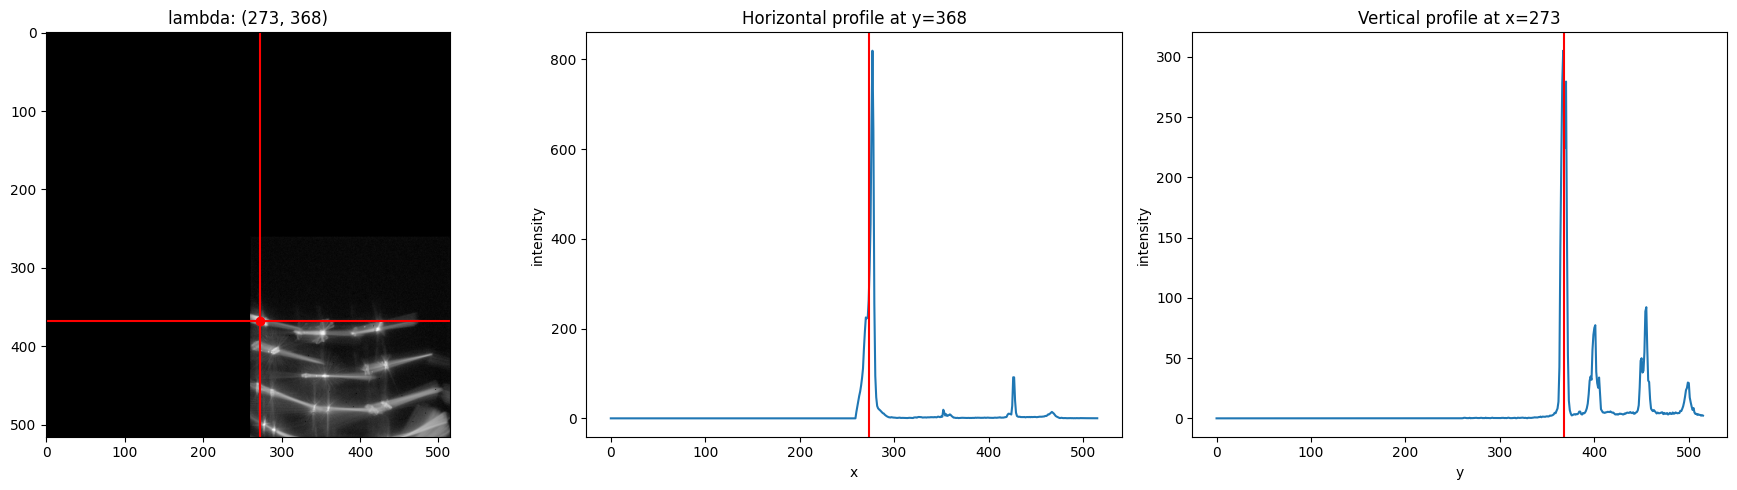

In [4]:
imgStack = lambda_data_list[0]
imgStack_M = minipix_data_list[0]

profile_detector = 'lambda'  # 'lambda' or 'minipix'
profile_x, profile_y = 273, 368
xrsp.plot_intensity_profile(
    {'lambda': imgStack, 'minipix': imgStack_M},
    profile_detector, profile_x, profile_y,
)


### 选择 ROI workflow
观察剖面后再设置 `ROI_MODE`：`regular` 读取矩形 ROI，`auto` 读取手动中心并生成非规则 ROI。

In [20]:
ROI_MODE = 'regular'  # 'regular' or 'auto'
useFilter = True
useAutoRoiAdjust = False  # regular workflow only
ROIsize = 30
filterVal = 0.15

roiFile = 'roi_60crystals-v3.txt'
roiFile_M = 'roi_minipix-v3.txt'
auto_roi_file = 'auto_ROI_lambda.txt'
auto_roi_file_M = 'auto_ROI_minipix.txt'
REGULAR_ROI_FILES = {
    'lambda': 'ROI/' + roiFile,
    'minipix': 'ROI/' + roiFile_M,
}
AUTO_ROI_FILES = {
    'lambda': 'ROI/' + auto_roi_file,
    'minipix': 'ROI/' + auto_roi_file_M,
}
if ROI_MODE not in ('regular', 'auto'):
    raise ValueError("ROI_MODE must be 'regular' or 'auto'")
if ROI_MODE == 'auto':
    useFilter = True

### 生成 ROI Mask
统一入口只执行所选分支。`auto` 文件使用三列 `roi_label x y`，支持制表符、逗号或空格分隔。

In [6]:
roi_workflow = await xrsp.build_roi_workflow(
    {'lambda': imgStack, 'minipix': imgStack_M},
    ROI_MODE,
    regular_files=REGULAR_ROI_FILES,
    auto_files=AUTO_ROI_FILES,
    use_auto_adjust=useAutoRoiAdjust,
    roi_size=ROIsize,
    filter_value=filterVal,
    source_label=f'{scanIDs[0]}_elastic',
)

lambda_roi = roi_workflow['lambda']
minipix_roi = roi_workflow['minipix']
rois, maskList = lambda_roi['rois'], lambda_roi['masks']
rois_M, maskList_M = minipix_roi['rois'], minipix_roi['masks']
num_pixel_list, stacked_roi_list = lambda_roi['num_pixels'], lambda_roi['stacked_rois']
num_pixel_list_M, stacked_roi_list_M = minipix_roi['num_pixels'], minipix_roi['stacked_rois']
stacked_img, stacked_img_M = lambda_roi['image'], minipix_roi['image']
x_shift_list = lambda_roi['adjustments']['x_shift']
y_shift_list = lambda_roi['adjustments']['y_shift']
x_expand_list = lambda_roi['adjustments']['x_expand']
y_expand_list = lambda_roi['adjustments']['y_expand']
x_shift_list_M = minipix_roi['adjustments']['x_shift']
y_shift_list_M = minipix_roi['adjustments']['y_shift']
x_expand_list_M = minipix_roi['adjustments']['x_expand']
y_expand_list_M = minipix_roi['adjustments']['y_expand']

[FAILED] VB-A3: insufficient intensity variation
[FAILED] VB-B3: insufficient intensity variation
[FAILED] VB-C1: insufficient intensity variation
[FAILED] VB-C2: insufficient intensity variation
[FAILED] VB-D1: insufficient intensity variation
[FAILED] VB-D2: insufficient intensity variation
[FAILED] VB-E1: insufficient intensity variation
[FAILED] VB-E2: insufficient intensity variation
[FAILED] HL-A1: insufficient intensity variation
[FAILED] HL-A2: insufficient intensity variation
[FAILED] HL-A3: insufficient intensity variation
[FAILED] HL-B2: insufficient intensity variation
[FAILED] HL-B3: insufficient intensity variation
[FAILED] HL-C1: insufficient intensity variation
[FAILED] HL-C2: insufficient intensity variation
[FAILED] HL-C3: insufficient intensity variation
[FAILED] HL-D1: insufficient intensity variation
[FAILED] HL-D2: insufficient intensity variation
[FAILED] VU-A2: insufficient intensity variation
[INFO] 14564 overlap pixels assigned to nearest centres
[FAILED] HB-A

### 第四步：检查生成结果
显示两个探测器的 mask、包围框和 ROI 标签；确认无误后继续计算弹性峰曲线。

ROI mode: auto | Lambda: 41 | Minipix: 3


(<Figure size 2000x1000 with 2 Axes>,
 array([<Axes: title={'center': 'lambda: 41 ROIs'}>,
        <Axes: title={'center': 'minipix: 3 ROIs'}>], dtype=object))

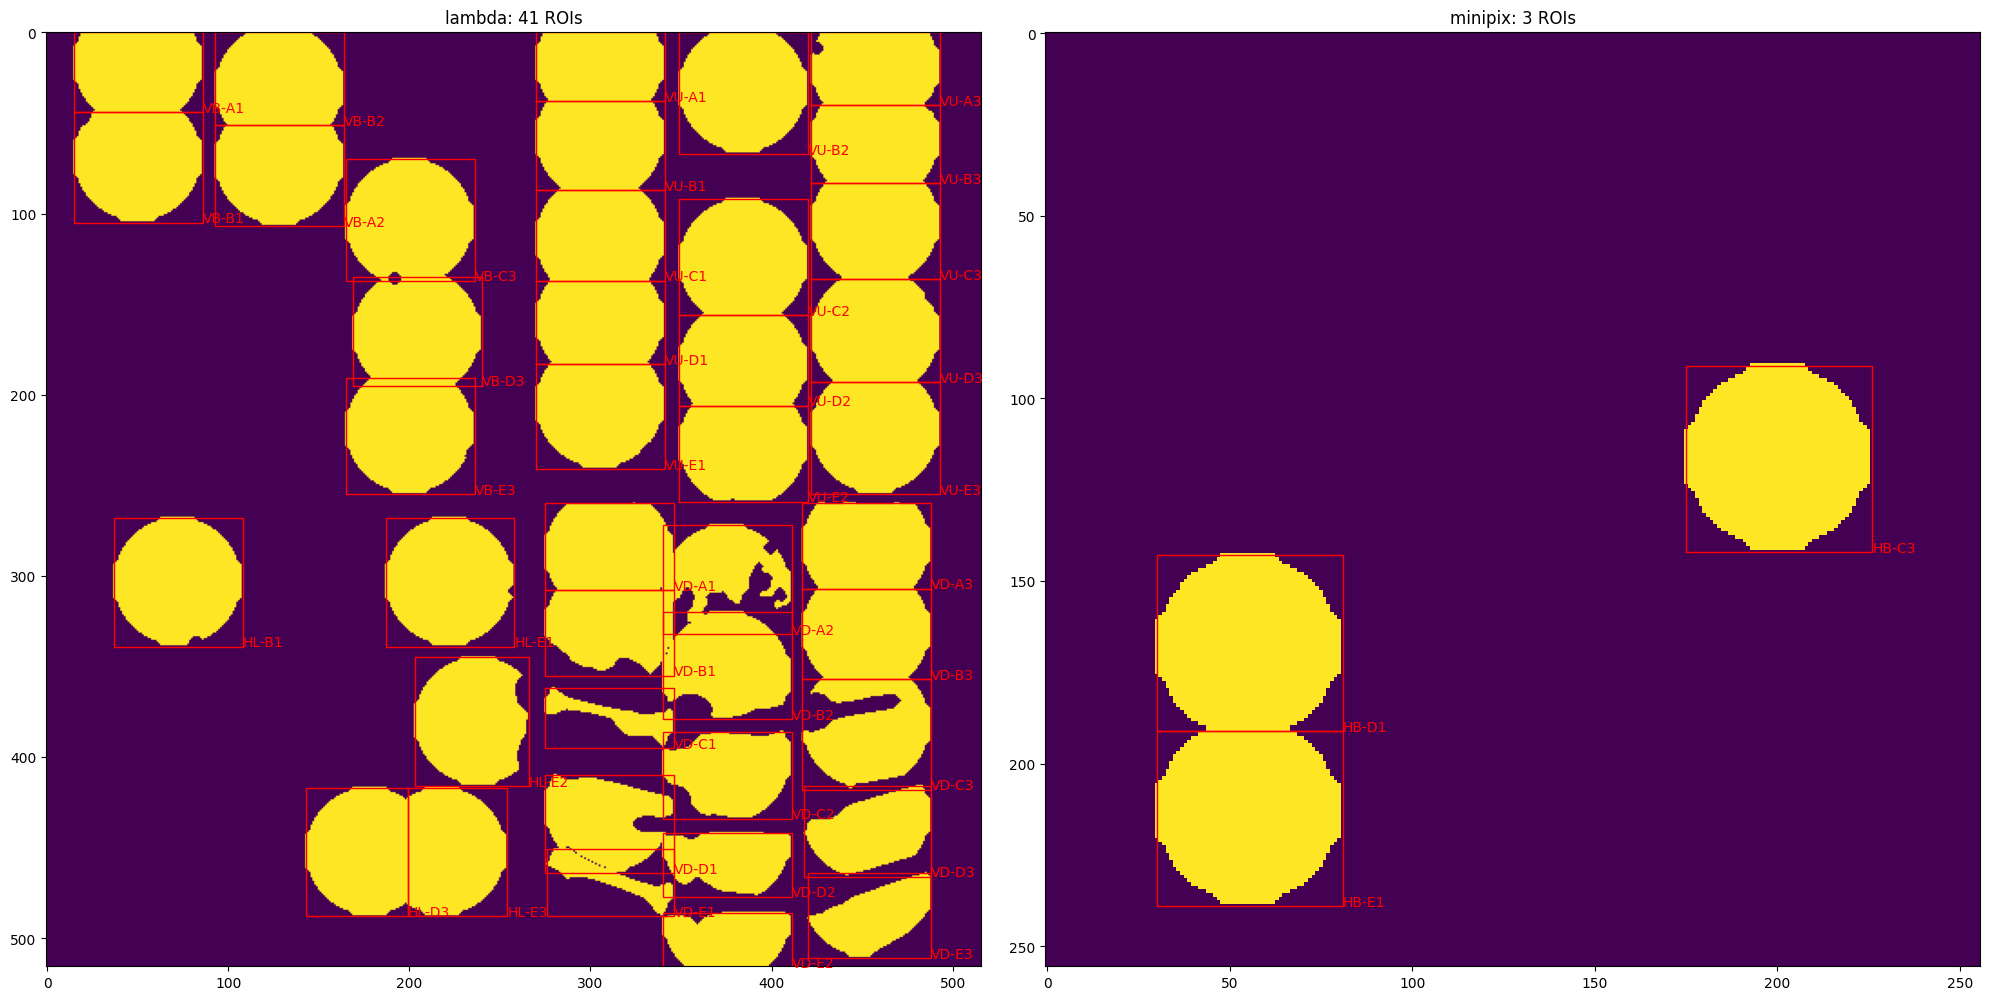

In [7]:
print('ROI mode:', ROI_MODE, '| Lambda:', len(rois), '| Minipix:', len(rois_M))
xrsp.plot_roi_masks(roi_workflow)

**各ROI弹性峰曲线**<br>
**输出结果**：左图为ROI整体积分数据，右图为经过Filter后的数据积分

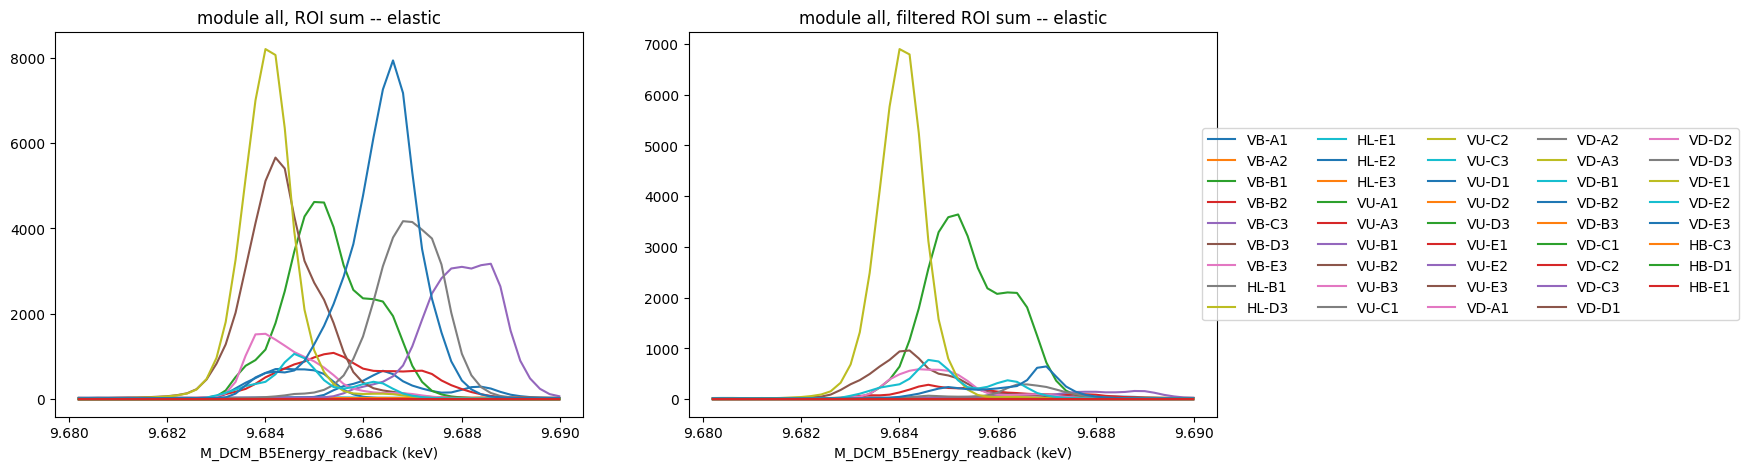

In [8]:
# ROI sum plot
module = "all"
energyPV = 'M_DCM_B5Energy_readback'
try: mot_data_list[0][energyPV]
except: energyPV = 'M_DCM_B5Link_Energy_readback'
energy = mot_data_list[0][energyPV]

ROISUMs,ROISUMs_filtered = [],[]
ROISUMs_M,ROISUMs_filtered_M = [],[]

fig, axs = plt.subplots(1,2, figsize=(15,5))
for i in range(len(rois)):
    if rois[i].name.startswith(module) or module not in moduleList:
        imgStack_filtered = np.copy(imgStack)
        for j in range(imgStack.shape[0]):
            imgStack_filtered[j]*=maskList[i] 
        #print(np.max(imgStack_filtered))
        roiStack = imgStack[:,rois[i].y1:rois[i].y2,rois[i].x1:rois[i].x2]
        roiStack_filtered = imgStack_filtered[:,rois[i].y1:rois[i].y2,rois[i].x1:rois[i].x2]
        sumVal = roiStack.sum(axis=(1,2))
        sumVal_filtered = roiStack_filtered.sum(axis=(1,2))
        ROISUMs.append(sumVal)
        ROISUMs_filtered.append(sumVal_filtered)
        axs[0].plot(energy[1:],sumVal[1:],label=rois[i].name)  
        axs[1].plot(energy[1:],sumVal_filtered[1:],label=rois[i].name)   
for i in range(len(rois_M)):
    if rois_M[i].name.startswith(module) or module not in moduleList:
        imgStack_filtered_M = np.copy(imgStack_M)
        for j in range(imgStack_M.shape[0]):
            imgStack_filtered_M[j]*=maskList_M[i] 
        #print(np.max(imgStack_filtered))
        roiStack_M = imgStack_M[:,rois_M[i].y1:rois_M[i].y2,rois_M[i].x1:rois_M[i].x2]
        roiStack_filtered_M = imgStack_filtered_M[:,rois_M[i].y1:rois_M[i].y2,rois_M[i].x1:rois_M[i].x2]
        sumVal_M = roiStack_M.sum(axis=(1,2))
        sumVal_filtered_M = roiStack_filtered_M.sum(axis=(1,2))
        ROISUMs_M.append(sumVal_M)
        ROISUMs_filtered_M.append(sumVal_filtered_M)
        axs[0].plot(energy[1:],sumVal_M[1:],label=rois_M[i].name)  
        axs[1].plot(energy[1:],sumVal_filtered_M[1:],label=rois_M[i].name)   
        
for k in range(2):
    axs[k].set_xlabel(energyPV+" (keV)")
axs[0].set_title("module "+module+', ROI sum -- elastic')
axs[1].set_title("module "+module+', filtered ROI sum -- elastic')
axs[1].legend(loc='center right',ncol=5,bbox_to_anchor=(2, 0.5))

**批量拟合弹性峰**<br>
energy_resolution_threshold: 弹性峰宽大于该数值时，判断为bad fit，后续数据加和时自动剔除该ROI<br>
r_squared_threshold: 峰形拟合的R平方值小于该数值时，判断为bad fit，后续数据加和时自动剔除该ROI<br>
E_lowlim: Si(660)——9.67, Si(880)——12.9<br>
E_highlim: Si(660)——9.69, Si(880)——12.92<br>
**输出结果**：各ROI拟合结果

In [9]:
# Batch fitting of elastic peaks
energy_resolution_threshold = 2
r_squared_threshold = 0.8
E_lowlim = 9.67
E_highlim = 9.69
BadFitList = []
fitType = xrsp.lorentzian # gauss, lorentzian
# p0 =(amp, cen, wid, bkg) is the initial guess for the fitting coefficients
import warnings
from scipy.optimize import OptimizeWarning

def fit_elastic_peak(x_values, y_values):
    x = np.asarray(x_values, dtype=float)
    y = np.asarray(y_values, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    center = x[np.argmax(y)] if x.size else np.nan
    p0 = np.array([np.ptp(y), center, 0.001, np.min(y)]) if y.size else np.array([0, np.nan, 0.001, 0])
    if x.size < 4 or np.ptp(y) <= np.finfo(float).eps:
        return p0, np.nan
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', OptimizeWarning)
            coeff, _ = curve_fit(fitType, x, y, p0=p0, maxfev=10000)
    except (RuntimeError, ValueError, TypeError):
        return p0, np.nan
    residuals = y - fitType(x, *coeff)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_squared = np.nan if ss_tot <= np.finfo(float).eps else 1 - ss_res / ss_tot
    return coeff, r_squared

centers, widths, amps, bkgs, rsqs = [],[],[],[],[]
for num in range(len(ROISUMs)):    
    x_raw = mot_data_list[0][energyPV]
    if useFilter==True: y_raw = ROISUMs_filtered[num]
    else: y_raw = ROISUMs[num]
    x_fit = x_raw
    coeff, r_squared = fit_elastic_peak(x_raw, y_raw)
    if not np.isfinite(r_squared) or not np.all(np.isfinite(coeff)) or r_squared<r_squared_threshold or coeff[1]<E_lowlim or coeff[1]>E_highlim or coeff[0]<0 or 2*np.abs(coeff[2])*1000>energy_resolution_threshold:
        BadFitList.append(rois[num].name)
        rois[num].elastic_energy = coeff[1]
    centers.append(coeff[1]*1000)
    widths.append(2*np.abs(coeff[2])*1000)
    amps.append(coeff[0])
    bkgs.append(coeff[3])
    rsqs.append(r_squared)

for num in range(len(ROISUMs_M)):    
    x_raw = mot_data_list[0][energyPV]
    if useFilter==True: y_raw = ROISUMs_filtered_M[num]
    else: y_raw = ROISUMs_M[num]
    x_fit = x_raw
    coeff, r_squared = fit_elastic_peak(x_raw, y_raw)
    if not np.isfinite(r_squared) or not np.all(np.isfinite(coeff)) or r_squared<r_squared_threshold or coeff[1]<E_lowlim or coeff[1]>E_highlim or coeff[0]<0 or 2*np.abs(coeff[2])*1000>energy_resolution_threshold:
        BadFitList.append(rois_M[num].name)
        rois_M[num].elastic_energy = coeff[1]
    centers.append(coeff[1]*1000)
    widths.append(2*np.abs(coeff[2])*1000)
    amps.append(coeff[0])
    bkgs.append(coeff[3])
    rsqs.append(r_squared)
    
print('Bad fit:', BadFitList)
fitResult = pd.DataFrame()
fitResult['crystal'],fitResult['x1'],fitResult['x2'],fitResult['y1'],fitResult['y2']=[roi.name for roi in rois]+[roi.name for roi in rois_M],[roi.x1 for roi in rois]+[roi.x1 for roi in rois_M],[roi.x2 for roi in rois]+[roi.x2 for roi in rois_M],[roi.y1 for roi in rois]+[roi.y1 for roi in rois_M],[roi.y2 for roi in rois]+[roi.y2 for roi in rois_M]
fitResult['center'],fitResult['width'],fitResult['height'],fitResult['background'],fitResult['r-square']=np.array(centers),np.array(widths),np.array(amps),np.array(bkgs),np.array(rsqs)
pd.set_option('display.max_rows', None)
fitResult

Bad fit: ['VB-A2', 'VB-B1', 'VB-C3', 'VB-D3', 'VB-E3', 'HL-B1', 'HL-D3', 'HL-E1', 'VU-A1', 'VU-A3', 'VU-C1', 'VU-C2', 'VU-C3', 'VU-D3', 'VU-E1', 'VU-E2', 'VU-E3', 'VD-A1', 'VD-A2', 'VD-A3', 'VD-B1', 'VD-B3', 'VD-C2', 'VD-C3', 'HB-D1', 'HB-E1']


,crystal,x1,x2,y1,y2,center,width,height,background,r-square
0,VB-A1,15,86,0,44,9685.196586,0.014508,0.061078,1.512521e-06,0.999966
1,VB-A2,93,164,51,107,9680.004993,2.000000,0.000000,0.000000e+00,NaN
2,VB-B1,15,86,44,105,9680.004993,2.000000,0.000000,0.000000e+00,NaN
3,VB-B2,93,164,0,51,9688.790269,0.004469,0.529759,-3.940437e-06,0.999996
4,VB-C3,165,236,70,137,9680.004993,2.000000,0.000000,0.000000e+00,NaN
5,VB-D3,169,240,135,195,9680.004993,2.000000,0.000000,0.000000e+00,NaN
6,VB-E3,165,236,191,255,9680.004993,2.000000,0.000000,0.000000e+00,NaN
7,HL-B1,37,108,268,339,9680.004993,2.000000,0.000000,0.000000e+00,NaN
8,HL-D3,143,199,417,488,9680.004993,2.000000,0.000000,0.000000e+00,NaN
9,HL-E1,187,258,268,339,9680.004993,2.000000,0.000000,0.000000e+00,NaN


**检查单个ROI的弹性峰拟合情况，和能量转移扣除情况**<br>
crystal_to_check：如果希望对某个ROI的拟合情况进行详细检查，输入该ROI对应的晶体名称<br>
**输出结果**：左图为希望检查的ROI拟合情况，右图为所有曲线将中心移动到零能量转移的情况，如果发现有峰没有移到中心，需要返回上一步检查对应的ROI

Text(0.5, 0, 'Energy Transfer (eV)')

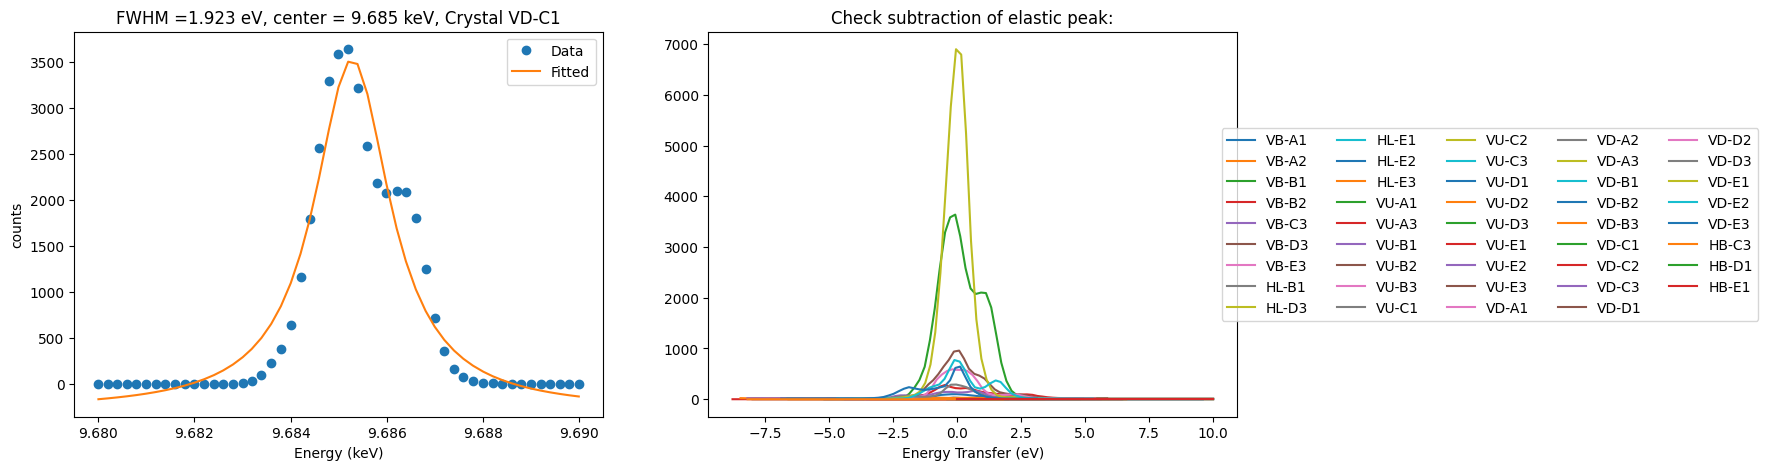

In [10]:
# Check fitting result of individual roi
crystal_to_check = 'VD-C1'
for i in range(len(rois)):
    if rois[i].name == crystal_to_check:
        if useFilter==True: y_raw = ROISUMs_filtered[i]
        else: y_raw = ROISUMs[i]
        crystNo = i
for i in range(len(rois_M)):
    if rois_M[i].name == crystal_to_check:
        if useFilter==True: y_raw = ROISUMs_filtered_M[i]
        else: y_raw = ROISUMs_M[i]
        crystNo = i
p0 = [np.max(y_raw), x_raw[np.argmax(y_raw)], 0.001, 0]
coeff, var_matrix = curve_fit(fitType, x_raw, y_raw, p0=p0)
res_fit = fitType(x_fit, *coeff)
fig, ax1 = plt.subplots(1,2, figsize=(15,5))

ax1[0].set_xlabel("Energy (keV)")
ax1[0].set_ylabel('counts')
ax1[0].plot(x_raw,y_raw,'o',label="Data",linestyle="None")
ax1[0].plot(x_fit, res_fit, label='Fitted')

ax1[0].set_title("FWHM ="+str(round(2.*np.abs(coeff[2]*1000),3))+" eV, center = "+str(round(coeff[1],3))+" keV, Crystal "+crystal_to_check)

ax1[0].legend()
for i in range(len(rois)):
    if useFilter==True: ax1[1].plot(energy*1000-fitResult["center"][i],ROISUMs_filtered[i],label=rois[i].name)
    else: ax1[1].plot(energy*1000-fitResult["center"][i],ROISUMs[i],label=rois[i].name)
for i in range(len(rois_M)):
    if useFilter==True: ax1[1].plot(energy*1000-fitResult["center"][i+len(rois)],ROISUMs_filtered_M[i],label=rois_M[i].name)
    else: ax1[1].plot(energy*1000-fitResult["center"][i+len(rois)],ROISUMs_M[i],label=rois_M[i].name)
ax1[1].legend(loc='center right',ncol=5,bbox_to_anchor=(2, 0.5))
ax1[1].set_title("Check subtraction of elastic peak:")
ax1[1].set_xlabel('Energy Transfer (eV)')
#ax1[0].set_ylim(0,20)

**导入XRS扫描**<br>
divideI0(True/False): XRS数据是否除以I0<br>
logFig(True/False): 后续XRS谱绘图是否使用log scale<br>
removeI0glitch(True/False): 是否去除I0数据中有奇异点<br>
I0_PV: 选择归一化使用的PV名，目前可以选择'D_SiC_I_A'或'D_QXBPM2_I_Sum'，需要带引号输入<br>
scanIDs2: XRS数据编号，支持多个数据，必须用方括号括住，数据编号间用逗号隔开<br>
**输出内容**：XRS数据内容简要总结，为每条数据新编了一个编号（圆括号内）

(0) Scan 14524 - 1
Motors: ['M_DCM_B5Energy_readback', 'M_DCM_B5Energy_setpoint', 'M_DCM_B5Energy_state']
1D detectors: ['D_K6517_Ch1', 'D_K6517_Ch10', 'D_K6517_Ch2', 'D_K6517_Ch3', 'D_K6517_Ch4', 'D_K6517_Ch5', 'D_K6517_Ch6', 'D_K6517_Ch7', 'D_K6517_Ch8', 'D_K6517_Ch9', 'D_K6517_value', 'D_LAMBDA_image', 'D_MINIPIX_image', 'D_QXBPM2_DeltaSumX', 'D_QXBPM2_DeltaSumY', 'D_QXBPM2_I_A', 'D_QXBPM2_I_B', 'D_QXBPM2_I_C', 'D_QXBPM2_I_D', 'D_QXBPM2_I_Sum', 'D_QXBPM_DeltaSumX', 'D_QXBPM_DeltaSumY', 'D_QXBPM_I_A', 'D_QXBPM_I_B', 'D_QXBPM_I_C', 'D_QXBPM_I_D', 'D_QXBPM_I_Sum', 'D_SiC_Acquire', 'D_SiC_Current1', 'D_SiC_Current2', 'D_SiC_Current3', 'D_SiC_Current4', 'D_SiC_CurrentScale1', 'D_SiC_CurrentScale2', 'D_SiC_CurrentScale3', 'D_SiC_CurrentScale4', 'D_SiC_DeltaSumX', 'D_SiC_DeltaSumY', 'D_SiC_I_A', 'D_SiC_I_B', 'D_SiC_I_C', 'D_SiC_I_D', 'D_SiC_Range1', 'D_SiC_Range2', 'D_SiC_Range3', 'D_SiC_Range4', 'D_ct08_1_count0', 'D_ct08_1_count1', 'D_ct08_1_count2', 'D_ct08_1_count3', 'D_ct08_1_count4',

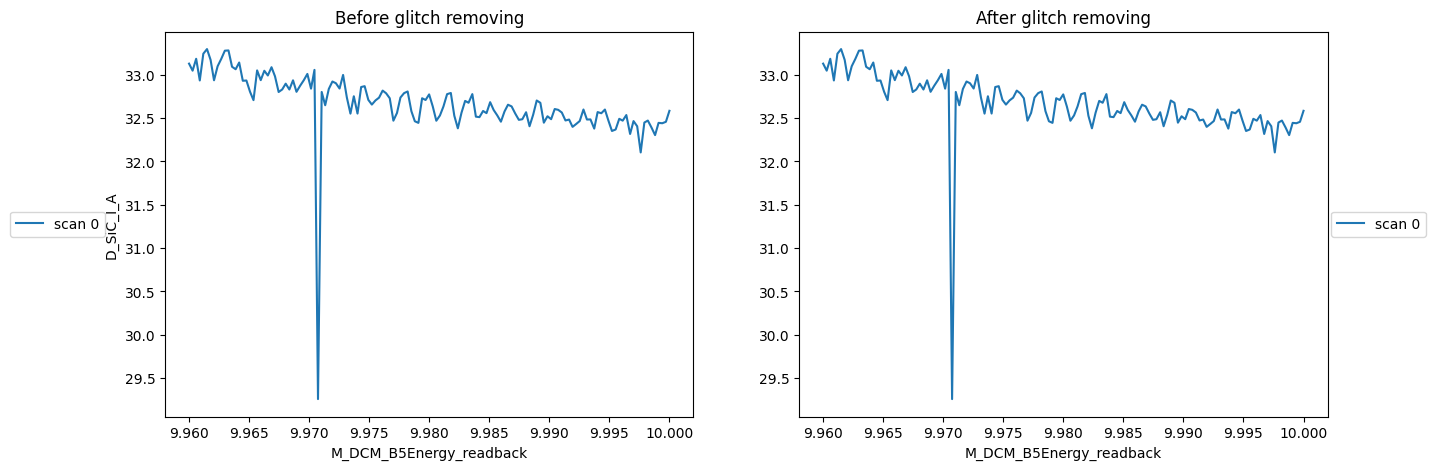

In [12]:
#Import XRS scans
divideI0 = True
removeI0glitch = True
logFig = False
I0_PV = 'D_SiC_I_A' ## 'D_QXBPM_I_Sum' or 'D_QXBPM2_I_Sum' or 'D_SiC_I_A'
energyPV2 = 'M_DCM_B5Energy_readback'
try:mot_data_list0[0][energyPV2]
except:energyPV2 ='M_DCM_B5Link_Energy_readback'
#print(energyPV2)
    
edge_scanIDs = [14524] 
path2 = path_raw
mot_list0, det1D_list0, det2D_list0, roi_list0, mot_data_list0, det1D_data_list0, det2D_data_list0, roi_data_list0 = xrsp.readH5(edge_scanIDs,path2,useROI=True)


if divideI0 == True:
    I0_list2 = [det1D_data[I0_PV] for det1D_data in det1D_data_list0]
    fig, axs = plt.subplots(1,2, figsize=(15,5))
    for j in range(len(I0_list2)):
        axs[0].plot(mot_data_list0[j][energyPV2],np.abs(I0_list2[j]),label='scan '+str(j))
    axs[0].set_title('Before glitch removing')
    axs[0].legend(loc='center right',ncol=2,bbox_to_anchor=(-0.1, 0.5))
    if removeI0glitch == True:
        for j in range(len(I0_list2)):
            glitch_count = 0
            for i in range(I0_list2[j].shape[0]-2):
                if I0_list2[j][i+1]/I0_list2[j][i]<0.7 and I0_list2[j][i+1]/I0_list2[j][i+2]<0.7: 
                    I0_list2[j][i+1]=(I0_list2[j][i]+I0_list2[j][i+2])/2
                    det2D_data_list0[j]['D_LAMBDA'][i+1] = (det2D_data_list0[j]['D_LAMBDA'][i]+det2D_data_list0[j]['D_LAMBDA'][i+2])/2
                    det2D_data_list0[j]['D_MINIPIX'][i+1] = (det2D_data_list0[j]['D_MINIPIX'][i]+det2D_data_list0[j]['D_MINIPIX'][i+2])/2
                    glitch_count += 1
            print(str(glitch_count)+' glitches removed in Scan '+str(j))
    for j in range(len(I0_list2)):
        axs[1].plot(mot_data_list0[j][energyPV2],np.abs(I0_list2[j]),label='scan '+str(j))
    axs[1].set_title('After glitch removing')
    axs[1].legend(loc='center right',ncol=2,bbox_to_anchor=(1.2, 0.5))
    axs[0].set_ylabel(I0_PV)
    [axs[i].set_xlabel(energyPV2) for i in [0,1]]
    
    lambda_data_list0 = [det2D_data['D_LAMBDA'] / np.abs(np.asarray(I0))[:, None, None] for det2D_data, I0 in zip(det2D_data_list0, I0_list2)]
    minipix_data_list0 = [det2D_data['D_MINIPIX'] / np.abs(np.asarray(I0))[:, None, None] for det2D_data, I0 in zip(det2D_data_list0, I0_list2)]
    factor=40
else: 
    lambda_data_list0 = [det2D_data['D_LAMBDA'] for det2D_data in det2D_data_list0]
    minipix_data_list0 = [det2D_data['D_MINIPIX'] for det2D_data in det2D_data_list0]

**检查I0数据**<br>
index_to_remove：检查I0数据，如果有不可用的数据（如掉光发生等），将编号输入这个列表，编号来自于上一步的圆括号内编号，也在本框运行后的图中出现<br>
**输出结果**：左侧为所有读入数据的I0,右侧为去掉不可用数据后真正参与后续运算的所有I0

[Text(0.5, 0, 'M_DCM_B5Energy_readback'),
 Text(0.5, 0, 'M_DCM_B5Energy_readback')]

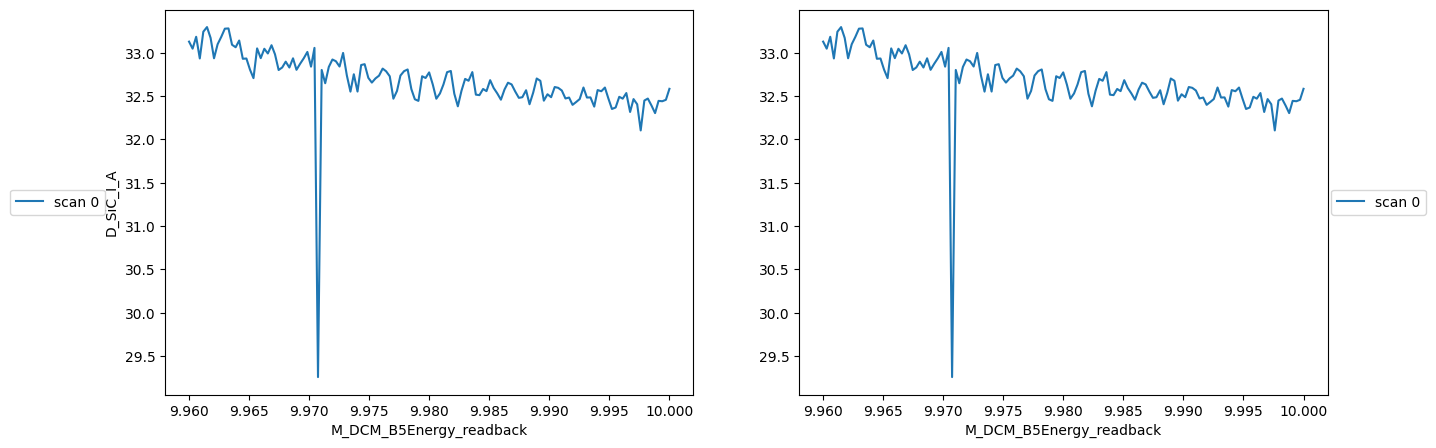

In [13]:
#Check I0
fig, ax1 = plt.subplots(1,2, figsize=(15,5))
for i in range(len(mot_data_list0)):
    if divideI0==True: ax1[0].plot(mot_data_list0[i][energyPV2],np.abs(I0_list2[i]),label='scan '+str(i))
    else: pass
ax1[0].legend(loc='center right',ncol=2,bbox_to_anchor=(-0.1, 0.5))

#Remove some of the scans
index_to_remove = []
#index_to_remove = [0,16,17,18]
#index_to_remove = [i+3 for i in range(17)]
mot_list2 = [element for i, element in enumerate(mot_list0) if i not in index_to_remove]
det1D_list2 = [element for i, element in enumerate(det1D_list0) if i not in index_to_remove]
det2D_list2 = [element for i, element in enumerate(det2D_list0) if i not in index_to_remove]
roi_list2 = [element for i, element in enumerate(roi_list0) if i not in index_to_remove]
mot_data_list2 = [element for i, element in enumerate(mot_data_list0) if i not in index_to_remove]
det1D_data_list2 = [element for i, element in enumerate(det1D_data_list0) if i not in index_to_remove]
roi_data_list2 = [element for i, element in enumerate(roi_data_list0) if i not in index_to_remove]
#det2D_data_list2 = [element for i, element in enumerate(det2D_data_list0) if i not in index_to_remove]
lambda_data_list2 = [element for i, element in enumerate(lambda_data_list0) if i not in index_to_remove]
minipix_data_list2 = [element for i, element in enumerate(minipix_data_list0) if i not in index_to_remove]
I0_list2 = [element for i, element in enumerate(I0_list2) if i not in index_to_remove]
#print(len(mot_data_list2))
for i in range(len(mot_data_list2)):
    if divideI0==True:ax1[1].plot(mot_data_list2[i][energyPV2],np.abs(I0_list2[i]),label='scan '+str(i))
    else: pass
ax1[1].legend(loc='center right',ncol=2,bbox_to_anchor=(1.2, 0.5))
ax1[0].set_ylabel(I0_PV)
[ax1[i].set_xlabel(energyPV2) for i in [0,1]]

**检查XRS所有图片叠加情况**<br>
**输出结果**: XRS所有数据图片叠加情况，同时画出最终参与运算的ROI，检查该图中光斑位置是否与弹性峰扫描有偏差

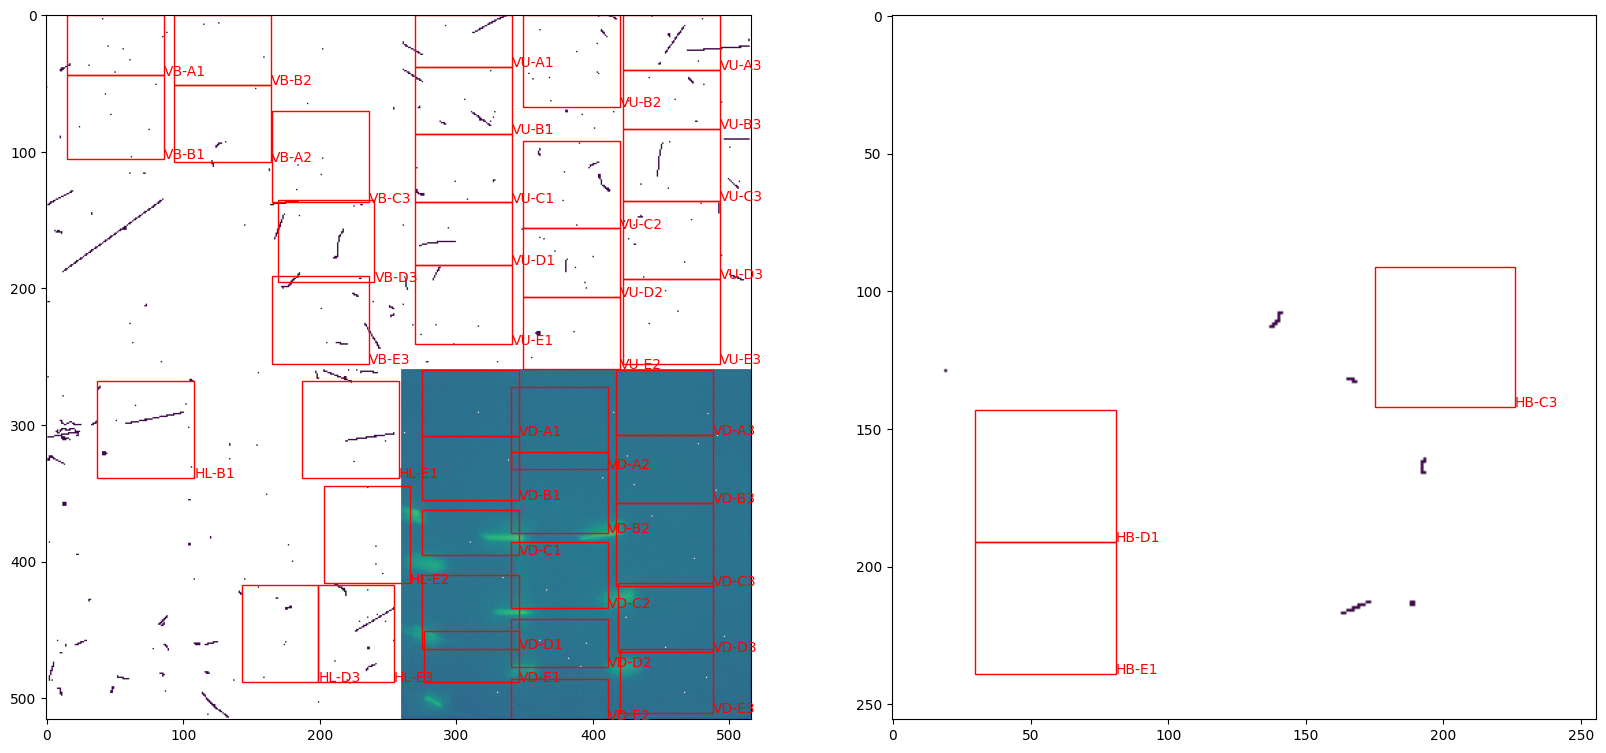

In [14]:
# 2D plot of the XRS scan
dataNo2 = 1
logPlot2 = True
plotStack2 = True
scanNo2 = 0
scanNum = len(mot_data_list2)
fig, axs = plt.subplots(1,2,figsize=(20,10))

imgStack2_list = []
imgStack2_stack = np.zeros_like(lambda_data_list2[0].sum(axis=0))
for i in range(scanNum):
    imgStack2 = lambda_data_list2[i]
    imgStack2_stack += imgStack2.sum(axis=0)
    imgStack2_list.append(imgStack2)
imgNo2 = 15
#fig, ax = plt.subplots(figsize=(10,10))  # Adjust width and height as needed
if logPlot2==True and plotStack2==False:axs[0].imshow(imgStack2[imgNo2], norm=LogNorm(vmin=0.1, vmax=100000/factor)) 
elif logPlot2==False and plotStack2==False:axs[0].imshow(imgStack2[imgNo2])
elif logPlot2==True and plotStack2==True:axs[0].imshow(imgStack2_stack, norm=LogNorm(vmin=0.1, vmax=100000/factor)) 
else:axs[0].imshow(imgStack2_stack,vmin=0,vmax=10000)
for i in range(len(rois)):
    axs[0].add_patch(Rectangle((rois[i].x1,rois[i].y1),rois[i].x_width,rois[i].y_width,edgecolor='red',facecolor='none',lw=1))
    axs[0].text(rois[i].x2,rois[i].y2,rois[i].name,color="red")

imgStack2_list_M = []
imgStack2_stack_M = np.zeros_like(minipix_data_list2[0].sum(axis=0))
for i in range(scanNum):
    imgStack2_M = minipix_data_list2[i]
    imgStack2_stack_M += imgStack2_M.sum(axis=0)
    imgStack2_list_M.append(imgStack2_M)
imgNo2 = 15
if logPlot2==True and plotStack2==False:axs[1].imshow(imgStack2_M[imgNo2], norm=LogNorm(vmin=0.1, vmax=100000/factor)) 
elif logPlot2==False and plotStack2==False:axs[1].imshow(imgStack2_M[imgNo2])
elif logPlot2==True and plotStack2==True:axs[1].imshow(imgStack2_stack_M, norm=LogNorm(vmin=0.1, vmax=100000/factor)) 
else:axs[2].imshow(imgStack2_stack_M,vmin=0,vmax=10000)
for i in range(len(rois_M)):
    axs[1].add_patch(Rectangle((rois_M[i].x1,rois_M[i].y1),rois_M[i].x_width,rois_M[i].y_width,edgecolor='red',facecolor='none',lw=1))
    axs[1].text(rois_M[i].x2,rois_M[i].y2,rois_M[i].name,color="red")

**所有ROI的XRS谱**<br>
**输出结果**: 左列为ROI直接积分，右图为经过Filter后的数据积分，从上到下为不同数据编号的谱

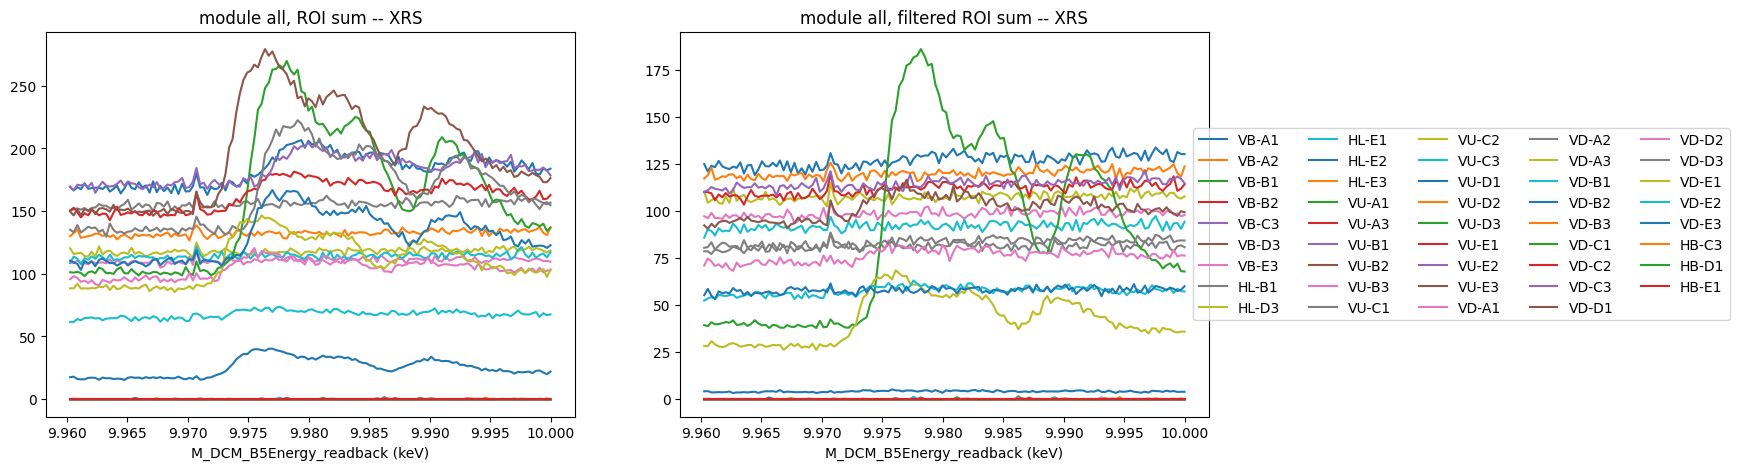

In [15]:
# ROI sum plot of the XRS spectra
logFig=False
module2 = "all"

energy2_list = []
ROISUMs2_list, ROISUMs_filtered2_list = [], []
ROISUMs2_list_M, ROISUMs_filtered2_list_M = [], []

fig, axs = plt.subplots(scanNum, 2, figsize=(15, 5*scanNum))

for ii in range(scanNum):
    #print(scanNum)
    energy2 = mot_data_list2[ii][energyPV2]
    #print(energy2.shape)
    imgStack = imgStack2_list[ii]  # shape = (Nimg, H, W)
    imgStack_M = imgStack2_list_M[ii]

    ROISUMs2, ROISUMs_filtered2 = [],[]
    ROISUMs2_M, ROISUMs_filtered2_M = [],[]

    # ---- 遍历 ROI ----
    for i, roi in enumerate(rois):

        # 过滤模块
        if not (roi.name.startswith(module2) or module2 not in moduleList):
            continue

        # 直接切片原数据
        roiStack = imgStack[:, roi.y1:roi.y2, roi.x1:roi.x2]

        # 一步完成“按 mask 筛选”，无需复制 imgStack
        maskedStack = roiStack * maskList[i][roi.y1:roi.y2, roi.x1:roi.x2]

        # ROI 求和（完全矢量化）
        sumVal = roiStack.sum(axis=(1, 2))
        sumVal_filtered = maskedStack.sum(axis=(1, 2))

        ROISUMs2.append(sumVal)
        ROISUMs_filtered2.append(sumVal_filtered)

        # ---- Plotting ----
        x = energy2[1:]  # 你原来跳过第 0 个
        if scanNum == 1:
            axs[0].plot(x, sumVal[1:], label=rois[i].name)
            axs[1].plot(x, sumVal_filtered[1:], label=rois[i].name)
        else:
            axs[ii][0].plot(x, sumVal[1:], label=rois[i].name)
            axs[ii][1].plot(x, sumVal_filtered[1:], label=rois[i].name)

    # ---- 遍历 ROI_M ----
    for i, roi in enumerate(rois_M):

        # 过滤模块
        if not (roi.name.startswith(module2) or module2 not in moduleList):
            continue

        # 直接切片原数据
        roiStack_M = imgStack_M[:, roi.y1:roi.y2, roi.x1:roi.x2]

        # 一步完成“按 mask 筛选”，无需复制 imgStack
        maskedStack_M = roiStack_M * maskList_M[i][roi.y1:roi.y2, roi.x1:roi.x2]

        # ROI 求和（完全矢量化）
        sumVal_M = roiStack_M.sum(axis=(1, 2))
        sumVal_filtered_M = maskedStack_M.sum(axis=(1, 2))

        ROISUMs2_M.append(sumVal_M)
        ROISUMs_filtered2_M.append(sumVal_filtered_M)

        # ---- Plotting ----
        x = energy2[1:]  # 你原来跳过第 0 个
        if scanNum == 1:
            axs[0].plot(x, sumVal_M[1:], label=rois_M[i].name)
            axs[1].plot(x, sumVal_filtered_M[1:], label=rois_M[i].name)
        else:
            axs[ii][0].plot(x, sumVal_M[1:], label=rois_M[i].name)
            axs[ii][1].plot(x, sumVal_filtered_M[1:], label=rois_M[i].name)

    # ---- Format ----
    if scanNum == 1:
        for k in range(2):
            axs[k].set_xlabel(energyPV2+" (keV)")
            if logFig:
                axs[k].set_yscale('log')
        axs[1].legend(loc='center right', ncol=5, bbox_to_anchor=(2, 0.5))
        axs[0].set_title(f"module {module2}, ROI sum -- XRS")
        axs[1].set_title(f"module {module2}, filtered ROI sum -- XRS")
    else:
        for k in range(2):
            axs[ii][k].set_xlabel(energyPV2+" (keV)")
            if logFig:
                axs[ii][k].set_yscale('log')
        axs[ii][1].legend(loc='center right', ncol=5, bbox_to_anchor=(2, 0.5))
        axs[ii][0].set_title(f"module {module2}, ROI sum -- XRS {ii}")
        axs[ii][1].set_title(f"module {module2}, filtered ROI sum -- XRS {ii}")

    energy2_list.append(energy2)
    ROISUMs2_list.append(ROISUMs2)
    ROISUMs_filtered2_list.append(ROISUMs_filtered2)
    ROISUMs2_list_M.append(ROISUMs2_M)
    ROISUMs_filtered2_list_M.append(ROISUMs_filtered2_M)

**检查单个ROI的XRS谱情况**<br>
crystal_to_check2：如果希望对某个ROI的XRS谱情况进行详细检查，输入该ROI对应的晶体名称<br>
**输出结果**：左列为ROI直接积分，右图为经过Filter后的数据积分，从上到下为不同数据编号的谱

135

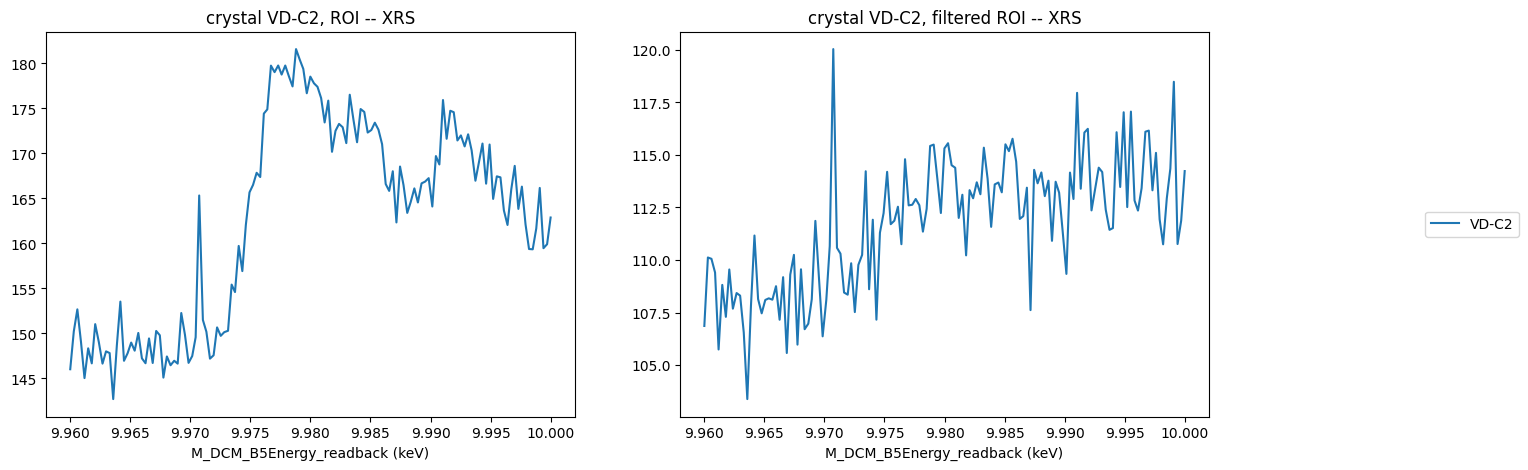

In [16]:
# check individual XRS spectrum
crystal_to_check2 = 'VD-C2'
fig, axs = plt.subplots(scanNum, 2, figsize=(15, 5*scanNum))
for ii in range(scanNum):
    for i in range(len(rois)):
        if rois[i].name == crystal_to_check2:
            if scanNum == 1:
                axs[0].plot(energy2_list[ii], ROISUMs2_list[ii][i], label=rois[i].name)
                # axs[0].errorbar(energy2_list[ii], y=ROISUMs2_list[ii][i], yerr=np.sqrt(ROISUMs2_list[ii][i]*I0_list2)/I0_list2, fmt='.', label=rois[i].name)
                axs[1].plot(energy2_list[ii], ROISUMs_filtered2_list[ii][i], label=rois[i].name)
                # axs[1].errorbar(energy2_list[ii], ROISUMs_filtered2_list[ii][i], yerr=np.sqrt(ROISUMs_filtered2_list[ii][i]*I0_list2)/I0_list2, fmt='.', label=rois[i].name)
            else:
                axs[ii][0].plot(energy2_list[ii], ROISUMs2_list[ii][i], label=rois[i].name)
                axs[ii][1].plot(energy2_list[ii], ROISUMs_filtered2_list[ii][i], label=rois[i].name)
    for i in range(len(rois_M)):
        if rois_M[i].name == crystal_to_check2:
            if scanNum == 1:
                axs[0].plot(energy2_list[ii], ROISUMs2_list_M[ii][i], label=rois_M[i].name)
                axs[1].plot(energy2_list[ii], ROISUMs_filtered2_list_M[ii][i], label=rois_M[i].name)
            else:
                axs[ii][0].plot(energy2_list[ii], ROISUMs2_list_M[ii][i], label=rois_M[i].name)
                axs[ii][1].plot(energy2_list[ii], ROISUMs_filtered2_list_M[ii][i], label=rois_M[i].name)
                
    if scanNum == 1:
        for k in range(2):
            axs[k].set_xlabel(energyPV2+" (keV)")
            if logFig:
                axs[k].set_yscale('log')
        axs[1].legend(loc='center right', ncol=3, bbox_to_anchor=(1.6, 0.5))
        axs[0].set_title(f"crystal {crystal_to_check2}, ROI -- XRS")
        axs[1].set_title(f"crystal {crystal_to_check2}, filtered ROI -- XRS")
    else:
        for k in range(2):
            axs[ii][k].set_xlabel(energyPV2+" (keV)")
            if logFig:
                axs[ii][k].set_yscale('log')
        axs[ii][1].legend(loc='center right', ncol=3, bbox_to_anchor=(1.6, 0.5))
        axs[ii][0].set_title(f"crystal {crystal_to_check2}, ROI -- XRS {ii}")
        axs[ii][1].set_title(f"crystal {crystal_to_check2}, filtered ROI -- XRS {ii}")
#axs[0].set_xlim(9.95,10.02)
#axs[0].set_ylim(0,2000)
len(energy2_list[0])

**Q计算**<br>
moduleAngleList: 输入模组整体所在的角度，顺序为['VB','VU','VD','HB','HL','HR']<br>
**输出结果**：ROI信息表格中增加q相关信息，q_ave为平均Q值

In [17]:
# Q calculation
#moduleList = ['VB','VU','VD','HB','HL','HR']
moduleAngleList = [np.deg2rad(i) for i in [145.6,79.03,25,118.8,58.85,67.862]]
for ROIs in [rois, rois_M]:
    for roi in ROIs:
        roi.q, roi.dq, roi.q_ave, roi.dq_ave,roi.q_range, roi.dq_range = xrsp.qCalc(moduleAngleList,roi.name,roi.elastic_energy,energy2)

fitResult['q_ave']=[roi.q_ave for roi in rois]+[roi.q_ave for roi in rois_M]
fitResult['dq_ave']=[roi.dq_ave for roi in rois]+[roi.dq_ave for roi in rois_M]
fitResult['q_range']=[roi.q_range for roi in rois]+[roi.q_range for roi in rois_M]
fitResult['dq_range']=[roi.dq_range for roi in rois]+[roi.dq_range for roi in rois_M]
fitResult

,crystal,x1,x2,y1,y2,center,width,height,background,r-square,q_ave,dq_ave,q_range,dq_range
0,VB-A1,15,86,0,44,9685.196586,0.014508,0.061078,1.512521e-06,0.999966,9.790528,0.086918,0.019923,0.000171
1,VB-A2,93,164,51,107,9680.004993,2.000000,0.000000,0.000000e+00,NaN,9.805735,0.082425,0.019958,0.000163
2,VB-B1,15,86,44,105,9680.004993,2.000000,0.000000,0.000000e+00,NaN,9.662789,0.113443,0.019676,0.000224
3,VB-B2,93,164,0,51,9688.790269,0.004469,0.529759,-3.940437e-06,0.999996,9.682223,0.110267,0.019709,0.000217
4,VB-C3,165,236,70,137,9680.004993,2.000000,0.000000,0.000000e+00,NaN,9.501651,0.140038,0.019359,0.000276
5,VB-D3,169,240,135,195,9680.004993,2.000000,0.000000,0.000000e+00,NaN,9.305238,0.166356,0.018972,0.000328
6,VB-E3,165,236,191,255,9680.004993,2.000000,0.000000,0.000000e+00,NaN,9.074292,0.192198,0.018517,0.000378
7,HL-B1,37,108,268,339,9680.004993,2.000000,0.000000,0.000000e+00,NaN,4.384120,0.417820,0.009477,0.000771
8,HL-D3,143,199,417,488,9680.004993,2.000000,0.000000,0.000000e+00,NaN,5.430838,0.390168,0.011441,0.000742
9,HL-E1,187,258,268,339,9680.004993,2.000000,0.000000,0.000000e+00,NaN,5.926301,0.374127,0.012387,0.000717


**数据内插并叠加(可自指定模组)**<br>
ROIremoveList: 需要手动剔除的晶体名<br>
module_add_list：需要叠加的模组名<br>
q_range: 需要叠加的Q范围上下限<br>
E_step: 内插能量间隔<br>
**输出结果**：第一个图为叠加的最终结果，其他图为所有谱经过能量平移后的结果

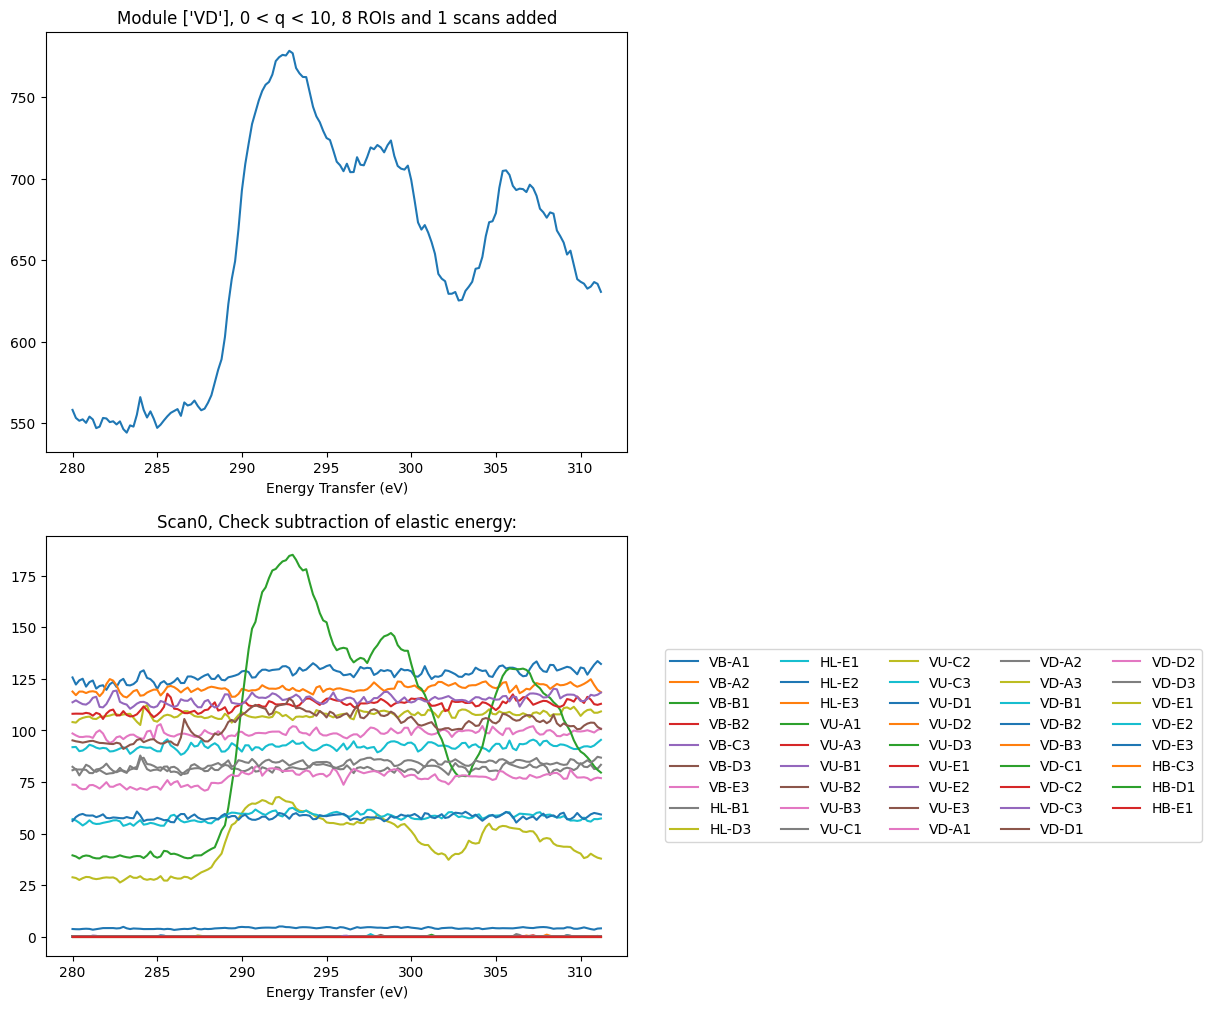

In [18]:
#Interpolate and add
ROIremoveList = []
# ROIremoveList = ['VU-B1']
# module_add_list = ['VU']
#module_add_list = ['HB']
#module_add_list = ['HB','VD','VU','VB']
#module_add_list = ['HB','VB']
#module_add_list = ['HB','VB','HL','VD','VU']
module_add_list = ['VD']
#ROI_chosen = ['VU-D1']

q_range = (0,10)
for ROIs in [rois, rois_M]:
    for roi in ROIs:
        roi.add = True
        if roi.name in ROIremoveList: roi.add = False
        if roi.name in BadFitList: roi.add = False
        if roi.name.split('-')[0] not in module_add_list: roi.add = False
        if roi.q_ave < q_range[0] or roi.q_ave > q_range[1]: roi.add = False
        #if roi.name not in ROI_chosen: roi.add = False

Estep = 0.2 #unit is eV
energy_upper_list, energy_lower_list = [], []
for ii in range(scanNum):
    for i in range(len(rois)):
        energy_upper_list.append(np.max(energy2_list[ii]*1000-fitResult["center"][i]))
        energy_lower_list.append(np.min(energy2_list[ii]*1000-fitResult["center"][i]))
    for i in range(len(rois_M)):
        energy_upper_list.append(np.max(energy2_list[ii]*1000-fitResult["center"][i+len(rois)]))
        energy_lower_list.append(np.min(energy2_list[ii]*1000-fitResult["center"][i+len(rois)]))
lower_E_interp = round(max(energy_lower_list)/Estep)*Estep    
upper_E_interp = round(min(energy_upper_list)/Estep)*Estep    
step_num = int((upper_E_interp-lower_E_interp)/Estep)
E_interp = np.linspace(lower_E_interp,upper_E_interp,step_num+1)

fig, axs = plt.subplots(scanNum+1,1, figsize=(7.5,6*(scanNum+1)))
interp_added = np.zeros_like(E_interp)
for ii in range(scanNum):
    roi_added_list = []
    count = 0
    for i in range(len(rois)):
        if useFilter == True: interp = np.interp(E_interp,energy2_list[ii]*1000-fitResult["center"][i], ROISUMs_filtered2_list[ii][i])
        else: interp = np.interp(E_interp,energy2_list[ii]*1000-fitResult["center"][i], ROISUMs2_list[ii][i])
        if rois[i].add == True: 
            interp_added+=interp
            roi_added_list.append(rois[i].name)
            count+=1
        axs[ii+1].plot(E_interp,interp,label=rois[i].name)  
    for i in range(len(rois_M)):
        if useFilter == True: interp = np.interp(E_interp,energy2_list[ii]*1000-fitResult["center"][i+len(rois)], ROISUMs_filtered2_list_M[ii][i])
        else: interp = np.interp(E_interp,energy2_list[ii]*1000-fitResult["center"][i+len(rois)], ROISUMs2_list_M[ii][i])
        if rois_M[i].add == True: 
            interp_added+=interp
            roi_added_list.append(rois_M[i].name)
            count+=1
        axs[ii+1].plot(E_interp,interp,label=rois_M[i].name)  
    axs[ii+1].set_title("Scan"+str(ii)+", Check subtraction of elastic energy:")
    axs[ii+1].legend(loc='center right',ncol=5,bbox_to_anchor=(2, 0.5))
axs[0].plot(E_interp,interp_added)
# axs[0].errorbar(E_interp, interp_added, yerr=np.sqrt(interp_added*I0_list2)/I0_list2, fmt='.',)
axs[0].set_title('Module '+str(module_add_list)+', '+str(q_range[0])+' < q < '+str(q_range[1])+', ' +str(count)+" ROIs and "+str(scanNum)+" scans added")
for k in range(scanNum+1):
    axs[k].set_xlabel("Energy Transfer (eV)")
    if logFig==True:
        axs[k].set_yscale('log')
# axs[0].set_ylim(0,7000)
#axs[0].set_xlim(0,200)

**存储内插叠加后的数据（自指定模组）**<br>
filename: 数据文件名<br>
程序将在processed文件夹中新建名为filename的文件夹并存储三个文件，data文件存储内插叠加数据，rois文件存储所有ROI信息，info文件存储数据处理相关信息

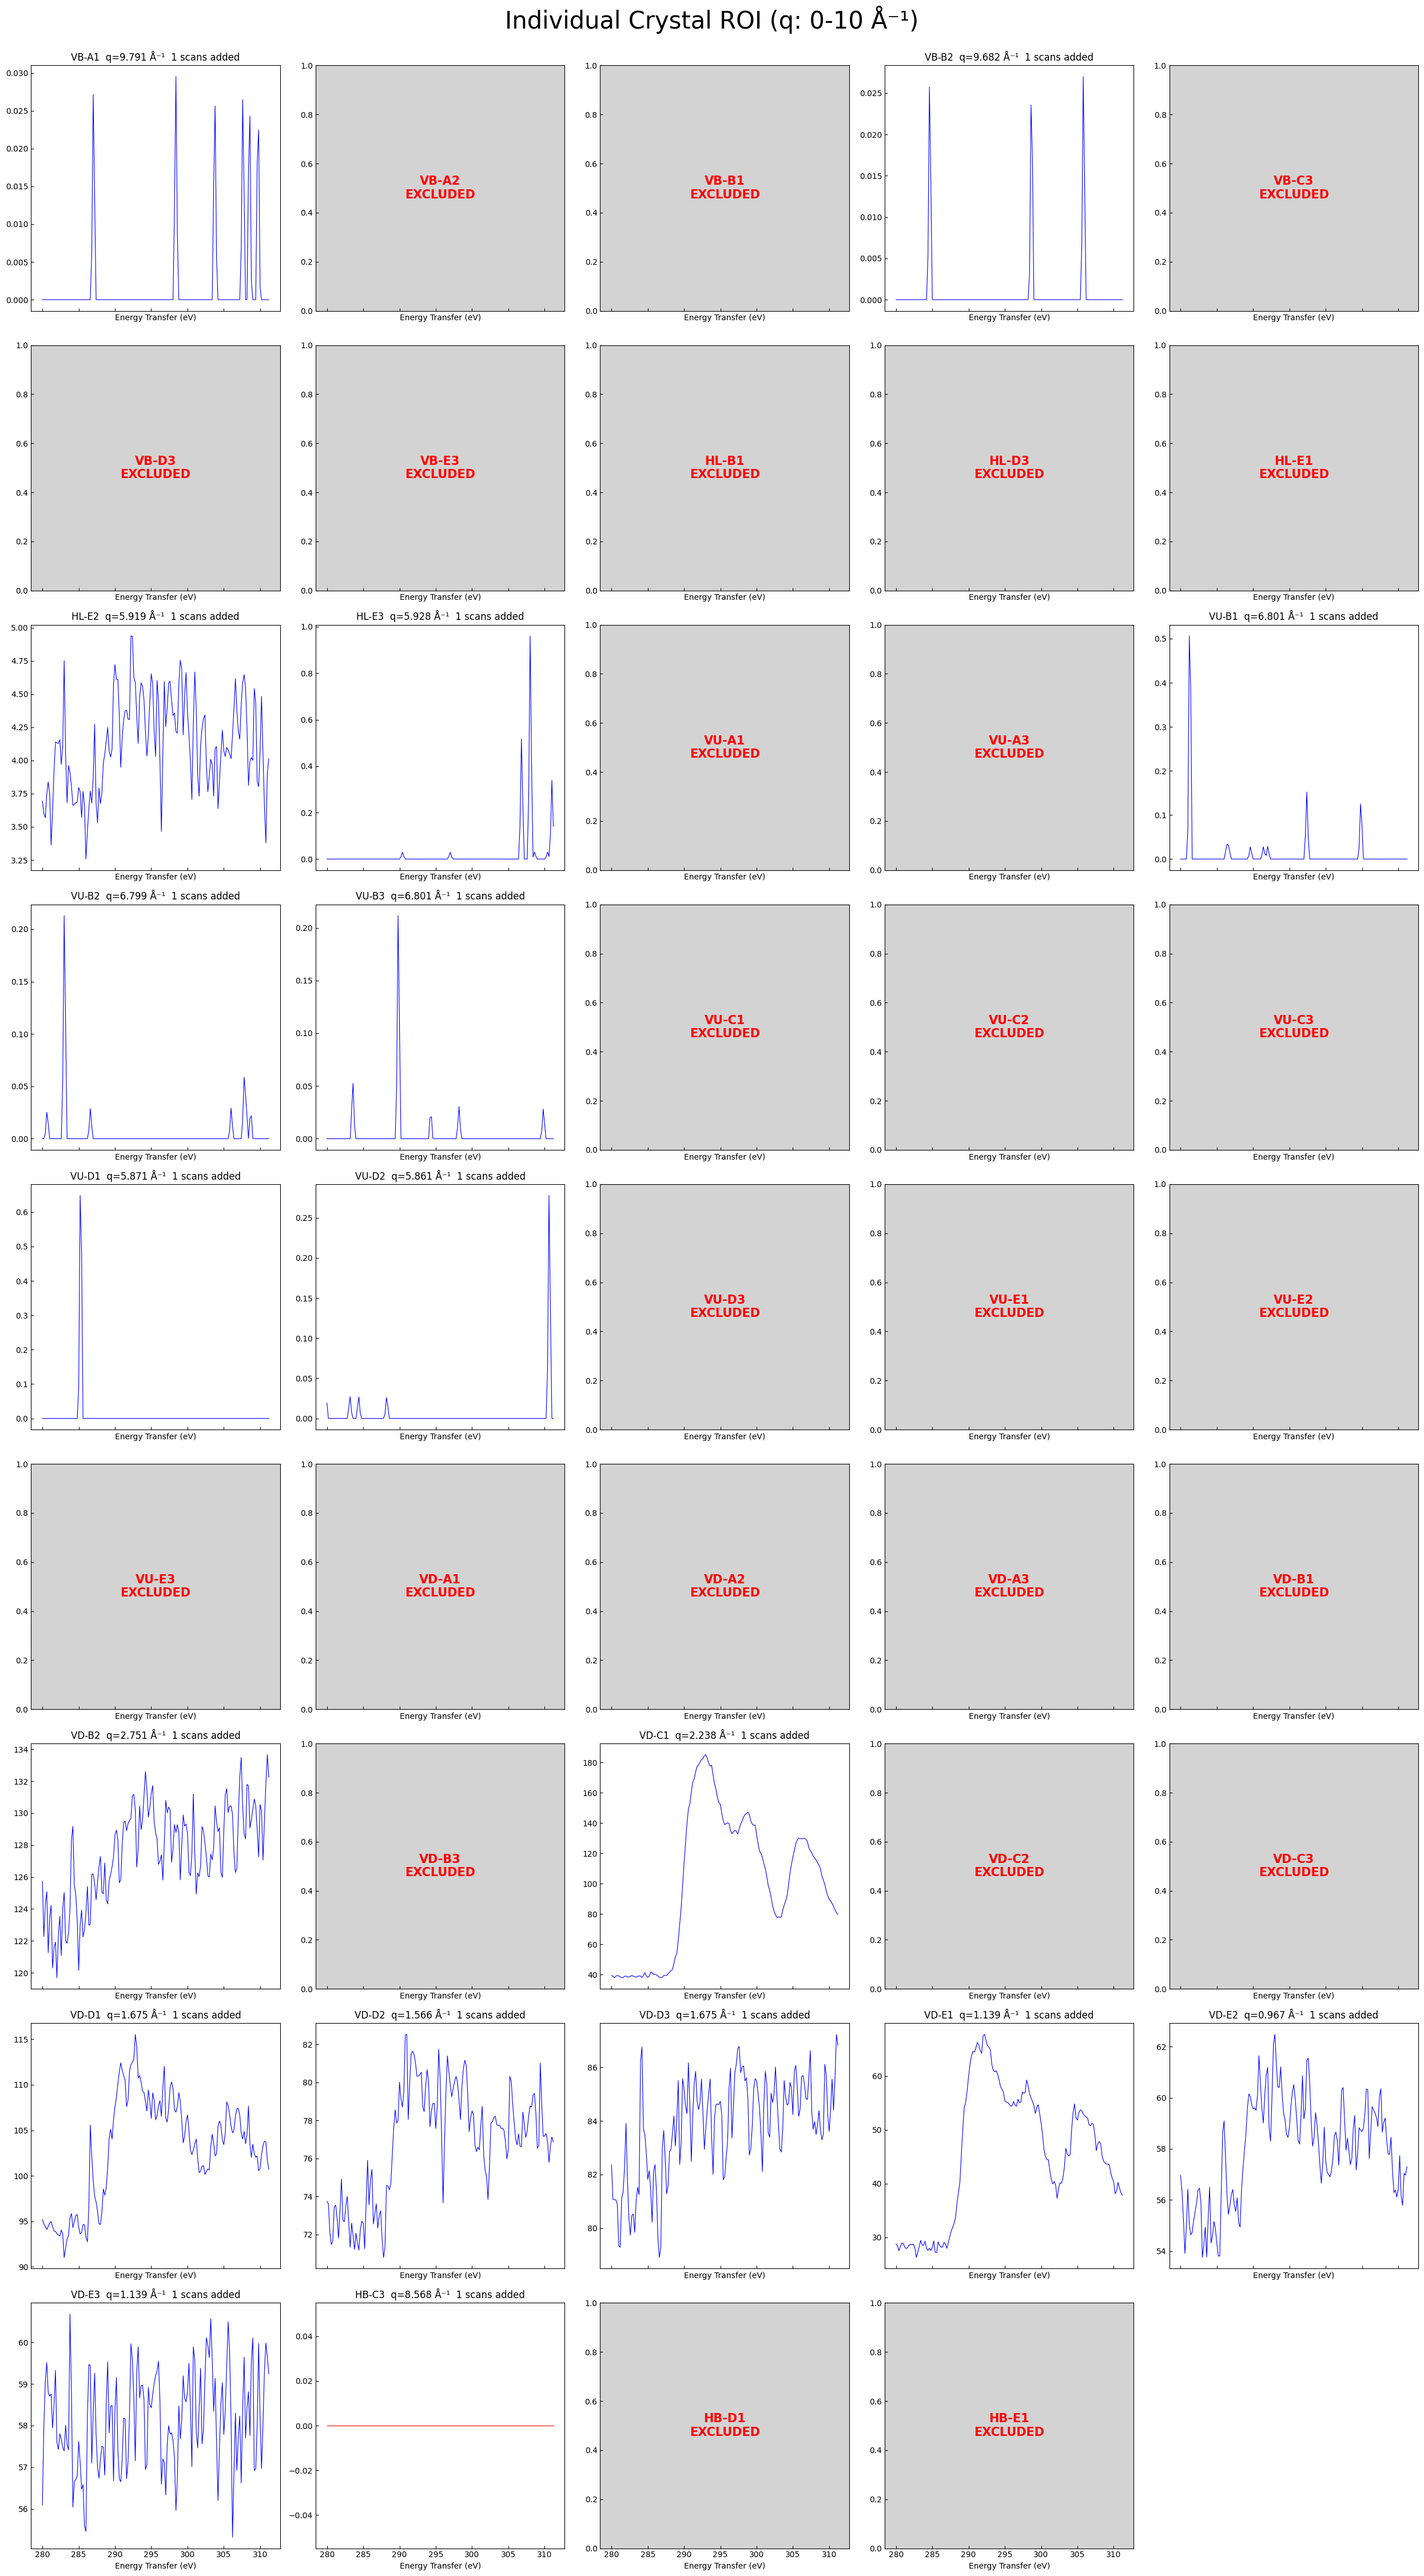

In [24]:
#Interpolate and add
# ROIremoveList = ['HL-A1','HL-A3']

Estep = 0.2  # unit is eV
q_range = (0, 10)

energy_upper_list, energy_lower_list = [], []
for ii in range(scanNum):
    for i in range(len(rois)):
        energy_upper_list.append(np.max(energy2_list[ii]*1000 - fitResult["center"][i]))
        energy_lower_list.append(np.min(energy2_list[ii]*1000 - fitResult["center"][i]))
    for i in range(len(rois_M)):
        energy_upper_list.append(np.max(energy2_list[ii]*1000 - fitResult["center"][i+len(rois)]))
        energy_lower_list.append(np.min(energy2_list[ii]*1000 - fitResult["center"][i+len(rois)]))

lower_E_interp = round(max(energy_lower_list)/Estep)*Estep    
upper_E_interp = round(min(energy_upper_list)/Estep)*Estep    
step_num = int((upper_E_interp - lower_E_interp)/Estep)
E_interp = np.linspace(lower_E_interp, upper_E_interp, step_num + 1)

# Create one panel per detected crystal.
n_rois, n_cols = len(rois) + len(rois_M), 5
n_rows = max(1, int(np.ceil(n_rois / n_cols)))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(25, 5*n_rows), sharex=True, sharey=False)
axs = axs.flatten()

all_interp_data = pd.DataFrame()
all_interp_data['Energy Transfer (eV)'] = E_interp

roi_idx = 0

for i in range(len(rois)):
    rois[i].add = True
    if rois[i].name in ROIremoveList: rois[i].add = False
    if rois[i].name in BadFitList: rois[i].add = False
    if rois[i].name.split('-')[0] not in moduleList: rois[i].add = False
    if rois[i].q_ave < q_range[0] or rois[i].q_ave > q_range[1]: rois[i].add = False
    
    ax = axs[roi_idx]
    
    if rois[i].add:
        # 有效晶体：所有 scan 累加后画一条曲线
        interp_total = np.zeros_like(E_interp)
        for ii in range(scanNum):
            if useFilter:
                interp = np.interp(E_interp, 
                                 energy2_list[ii]*1000 - fitResult["center"][i], 
                                 ROISUMs_filtered2_list[ii][i])
            else:
                interp = np.interp(E_interp, 
                                 energy2_list[ii]*1000 - fitResult["center"][i], 
                                 ROISUMs2_list[ii][i])
            interp_total += interp
        
        all_interp_data[rois[i].name] = interp_total
        
        ax.plot(E_interp, interp_total, color='blue', linewidth=0.8)
        ax.set_ylim(auto=True)
        ax.set_title(f"{rois[i].name}  q={rois[i].q_ave:.3f} Å⁻¹  {scanNum} scans added", fontsize=12)
    else:
        # 被排除晶体
        ax.set_facecolor('lightgray')
        ax.text(0.5, 0.5, f'{rois[i].name}\nEXCLUDED', 
                transform=ax.transAxes, ha='center', va='center',
                color='red', fontsize=15, fontweight='bold')
        ax.set_ylim(0, 1)

    # ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    ax.tick_params(axis='both', which='major', labelsize=10, direction='in')
    roi_idx += 1

for i in range(len(rois_M)):
    rois_M[i].add = True
    if rois_M[i].name in ROIremoveList: rois_M[i].add = False
    if rois_M[i].name in BadFitList: rois_M[i].add = False
    if rois_M[i].name.split('-')[0] not in moduleList: rois_M[i].add = False
    if rois_M[i].q_ave < q_range[0] or rois_M[i].q_ave > q_range[1]: rois_M[i].add = False
    
    ax = axs[roi_idx]
    
    if rois_M[i].add:
        # 有效晶体：所有 scan 累加后画一条曲线
        interp_total = np.zeros_like(E_interp)
        for ii in range(scanNum):
            if useFilter:
                interp = np.interp(E_interp, 
                                 energy2_list[ii]*1000 - fitResult["center"][i+len(rois)], 
                                 ROISUMs_filtered2_list_M[ii][i])
            else:
                interp = np.interp(E_interp, 
                                 energy2_list[ii]*1000 - fitResult["center"][i+len(rois)], 
                                 ROISUMs2_list_M[ii][i])
            interp_total += interp
        
        all_interp_data[rois_M[i].name] = interp_total
        
        ax.plot(E_interp, interp_total, color='red', linewidth=0.8)
        ax.set_ylim(auto=True)
        ax.set_title(f"{rois_M[i].name}  q={rois_M[i].q_ave:.3f} Å⁻¹  {scanNum} scans added", fontsize=12)
    else:
        ax.set_facecolor('lightgray')
        ax.text(0.5, 0.5, f'{rois_M[i].name}\nEXCLUDED', 
                transform=ax.transAxes, ha='center', va='center',
                color='red', fontsize=15, fontweight='bold')
        ax.set_ylim(0, 1)
    
    # ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    ax.tick_params(axis='both', which='major', labelsize=10, direction='in')
    roi_idx += 1

for k in range(len(axs)):
    axs[k].set_xlabel("Energy Transfer (eV)")

# 隐藏多余的子图（如果有的话）
for idx in range(roi_idx, len(axs)):
    fig.delaxes(axs[idx])

fig.suptitle(f'Individual Crystal ROI (q: {q_range[0]}-{q_range[1]} Å⁻¹)', 
             fontsize=30, y=1)
fig.tight_layout()

plt.show()

In [19]:
# Save the interpolated data
filename = '9586-9588-Be-VDE-1'
path_processed = path+'processed/'
os.mkdir(path_processed+filename)
path3 = path_processed+filename+'/'
interpolated_data = pd.DataFrame()
interpolated_data['Energy Transfer (eV)'] = E_interp
interpolated_data['Intensity'] = interp_added
#interpolated_data.apply(lambda x: round(x, 2))
#precision = {'Energy Transfer (eV)': lambda x: f'{x:.2f}','Intensity': lambda x: f'{x:.4f}'}
#interpolated_data.to_csv(path3+filename+'_data.txt',sep='\t',mode='x', float_format=precision)
interpolated_data.to_csv(path3+filename+'_data.txt',sep='\t',mode='x')
fitResult.to_csv(path3+filename+'_rois.txt',sep='\t',mode='x')
with open(path3+filename+'_info.txt', 'w') as file:
    file.write('ROI_MODE = '+ROI_MODE+'\n')
    file.write('useFilter = '+str(useFilter)+'\n')
    file.write('useAutoRoiAdjust = '+str(useAutoRoiAdjust)+'\n')
    file.write('divideI0 (elastic) = '+str(divideI0_elastic)+'\n')
    file.write('scanIDs (elastic) = '+str(scanIDs)+'\n')
    file.write('roiFile = '+str(roiFile)+'\n')
    file.write('ROIsize = '+str(ROIsize)+'\n')
    file.write('filterVal = '+str(filterVal)+'\n')
    file.write('energyPV (elastic) = '+str(energyPV)+'\n')
    file.write('energy_resolution_threshold = '+str(energy_resolution_threshold)+'\n')
    file.write('r_squared_threshold = '+str(r_squared_threshold)+'\n')
    file.write('BadFitList = '+str(BadFitList)+'\n')
    file.write('divideI0 (XRS) = '+str(divideI0)+'\n')
    file.write('I0_PV (XRS) = '+str(I0_PV)+'\n')
    file.write('scanIDs (XRS) = '+str(scanIDs2)+'\n')
    file.write('energyPV (XRS) = '+str(energyPV2)+'\n')
    file.write('ROIremoveList = '+str(ROIremoveList)+'\n')
    file.write('module_add_list = '+str(module_add_list)+'\n')
    file.write('moduleAngleList = '+str(moduleAngleList)+'\n')
    file.write('q_range = '+str(q_range)+'\n')
    file.write('Energy interpolation step = '+str(Estep)+' eV \n')


FileExistsError: [Errno 17] File exists: '/hepsdatafs/ID33/202504/Data/GID33-250416-01/processed/9586-9588-Be-VDE-1'

**数据内插并叠加(分模组存储)**<br>
ROIremoveList: 需要手动剔除的晶体名<br>
q_range: 需要叠加的Q范围上下限<br>
E_step: 内插能量间隔<br>
**输出结果**：第一个图为叠加的最终结果，其他图为所有谱经过能量平移后的结果

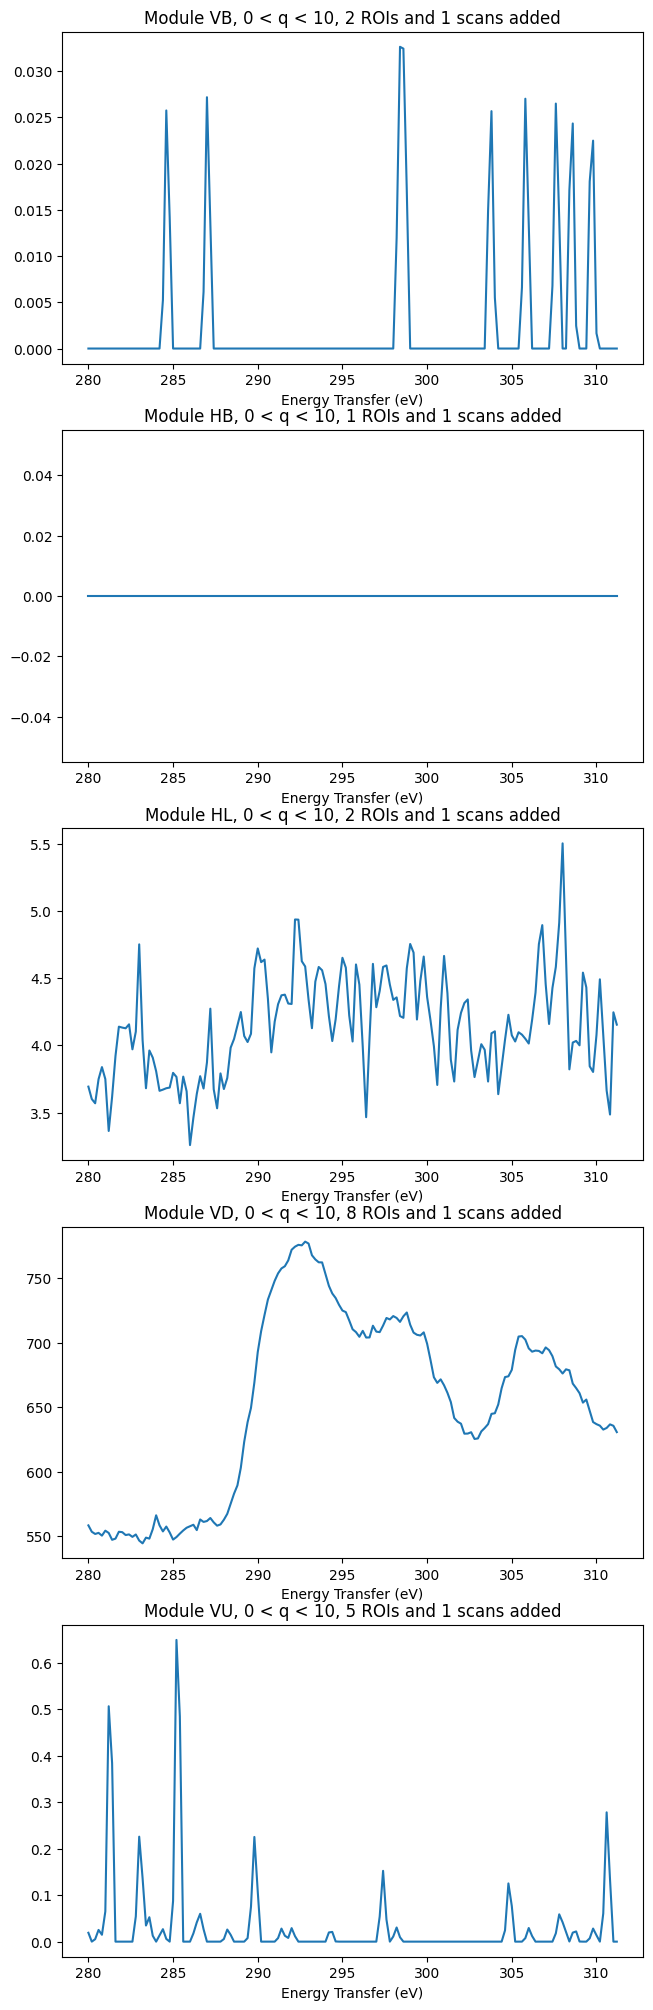

In [21]:
#Interpolate and add
# ROIremoveList = ['HL-A1','HL-A3']

q_range = (0,10)
Estep = 0.2 #unit is eV
fig, axs = plt.subplots(len(moduleList),1, figsize=(7.5,25))
interpolated_data = pd.DataFrame()
for j in range(len(moduleList)):
    for ROIs in [rois, rois_M]:
        for roi in ROIs:
            roi.add = True
            if roi.name in ROIremoveList: roi.add = False
            if roi.name in BadFitList: roi.add = False
            if roi.name.split('-')[0] != moduleList[j]: roi.add = False
            if roi.q_ave < q_range[0] or roi.q_ave > q_range[1]: roi.add = False

    energy_upper_list, energy_lower_list = [], []
    for ii in range(scanNum):
        for i in range(len(rois)):
            energy_upper_list.append(np.max(energy2_list[ii]*1000-fitResult["center"][i]))
            energy_lower_list.append(np.min(energy2_list[ii]*1000-fitResult["center"][i]))
        for i in range(len(rois_M)):
            energy_upper_list.append(np.max(energy2_list[ii]*1000-fitResult["center"][i+len(rois)]))
            energy_lower_list.append(np.min(energy2_list[ii]*1000-fitResult["center"][i+len(rois)]))
    lower_E_interp = round(max(energy_lower_list)/Estep)*Estep
    upper_E_interp = round(min(energy_upper_list)/Estep)*Estep
    step_num = int((upper_E_interp-lower_E_interp)/Estep)
    E_interp = np.linspace(lower_E_interp,upper_E_interp,step_num+1)
        
    interp_added = np.zeros_like(E_interp)
    for ii in range(scanNum):
        roi_added_list = []
        count = 0
        for i in range(len(rois)):
            if useFilter == True: interp = np.interp(E_interp,energy2_list[ii]*1000-fitResult["center"][i], ROISUMs_filtered2_list[ii][i])
            else: interp = np.interp(E_interp,energy2_list[ii]*1000-fitResult["center"][i], ROISUMs2_list[ii][i])
            if rois[i].add == True: 
                interp_added+=interp
                roi_added_list.append(rois[i].name)
                count+=1
                #print(roi_added_list) 
        for i in range(len(rois_M)):
            if useFilter == True: interp = np.interp(E_interp,energy2_list[ii]*1000-fitResult["center"][i+len(rois)], ROISUMs_filtered2_list_M[ii][i])
            else: interp = np.interp(E_interp,energy2_list[ii]*1000-fitResult["center"][i+len(rois)], ROISUMs2_list_M[ii][i])
            if rois_M[i].add == True: 
                interp_added+=interp
                roi_added_list.append(rois_M[i].name)
                count+=1
    axs[j].plot(E_interp,interp_added)
    #axs[j].set_ylim(0,10000)
    axs[j].set_title('Module '+str(moduleList[j])+', '+str(q_range[0])+' < q < '+str(q_range[1])+', ' +str(count)+" ROIs and "+str(scanNum)+" scans added")
    interpolated_data['Energy Transfer (eV)'] = E_interp
    interpolated_data[moduleList[j]] = interp_added    
for k in range(5):
    axs[k].set_xlabel("Energy Transfer (eV)")
    if logFig==True:
        axs[k].set_yscale('log')

**存储内插叠加后的数据(分模组存储)**<br>
filename: 数据文件名<br>
程序将在processed文件夹中新建名为filename的文件夹并存储三个文件，data文件存储内插叠加数据，rois文件存储所有ROI信息，info文件存储数据处理相关信息

In [22]:
# Save the interpolated data
filename = 'NiO@2_20260518'
path_processed = path+'processed/'
os.mkdir(path_processed+filename)
path3 = path_processed+filename+'/'
#interpolated_data = pd.DataFrame()

#interpolated_data.apply(lambda x: round(x, 2))
#precision = {'Energy Transfer (eV)': lambda x: f'{x:.2f}','Intensity': lambda x: f'{x:.4f}'}
#interpolated_data.to_csv(path3+filename+'_data.txt',sep='\t',mode='x', float_format=precision)
interpolated_data.to_csv(path3+filename+'_data.txt',sep='\t',mode='x')
fitResult.to_csv(path3+filename+'_rois.txt',sep='\t',mode='x')
with open(path3+filename+'_info.txt', 'w') as file:
    file.write('ROI_MODE = '+ROI_MODE+'\n')
    file.write('useFilter = '+str(useFilter)+'\n')
    file.write('useAutoRoiAdjust = '+str(useAutoRoiAdjust)+'\n')
    file.write('divideI0 (elastic) = '+str(divideI0_elastic)+'\n')
    file.write('scanIDs (elastic) = '+str(scanIDs)+'\n')
    file.write('roiFile = '+str(roiFile)+'\n')
    file.write('ROIsize = '+str(ROIsize)+'\n')
    file.write('filterVal = '+str(filterVal)+'\n')
    file.write('energyPV (elastic) = '+str(energyPV)+'\n')
    file.write('energy_resolution_threshold = '+str(energy_resolution_threshold)+'\n')
    file.write('r_squared_threshold = '+str(r_squared_threshold)+'\n')
    file.write('BadFitList = '+str(BadFitList)+'\n')
    file.write('divideI0 (XRS) = '+str(divideI0)+'\n')
    file.write('I0_PV (XRS) = '+str(I0_PV)+'\n')
    file.write('scanIDs (XRS) = '+str(scanIDs2)+'\n')
    file.write('energyPV (XRS) = '+str(energyPV2)+'\n')
    file.write('ROIremoveList = '+str(ROIremoveList)+'\n')
    #file.write('module_add_list = '+str(module_add_list)+'\n')
    file.write('moduleAngleList = '+str(moduleAngleList)+'\n')
    file.write('q_range = '+str(q_range)+'\n')
    file.write('Energy interpolation step = '+str(Estep)+' eV \n')


FileExistsError: [Errno 17] File exists: '/hepsdatafs/ID33/202504/Data/GID33-250416-01/processed/NiO@2_20260518'

In [25]:
# Save the interpolated data
filename = 'Ho_Comptonscan_crystaldivided'
path_processed = path + 'processed/'
os.makedirs(path_processed + filename, exist_ok=True)  
path3 = path_processed + filename + '/'

for roi_name in all_interp_data.columns:
    if roi_name == 'Energy Transfer (eV)':
        continue  
    
    # 每个晶体单独一个 DataFrame
    single_roi_data = pd.DataFrame({
        'Energy Transfer (eV)': all_interp_data['Energy Transfer (eV)'],
        'Intensity': all_interp_data[roi_name]
    })
    
    # 文件名用晶体名
    safe_name = roi_name.replace('/', '_').replace('\\', '_')
    single_roi_data.to_csv(path3 + safe_name + '_data.txt', sep='\t', mode='x', float_format='%.6f')

# 存储汇总数据（所有晶体在一个文件）
all_interp_data.to_csv(path3 + filename + '_all_data.txt', sep='\t', mode='x', float_format='%.6f')

# 存储 fitResult
fitResult.to_csv(path3 + filename + '_rois.txt', sep='\t', mode='x')

# 存储 info 文件
with open(path3 + filename + '_info.txt', 'w') as file:
    file.write('Data type = Individual ROI profiles (' + str(len(rois)+len(rois_M)) + ' crystals)\n')
    file.write('ROI_MODE = ' + ROI_MODE + '\n')
    file.write('useFilter = ' + str(useFilter) + '\n')
    file.write('useAutoRoiAdjust = ' + str(useAutoRoiAdjust) + '\n')
    file.write('divideI0 (elastic) = ' + str(divideI0_elastic) + '\n')
    file.write('scanIDs (elastic) = ' + str(scanIDs) + '\n')
    file.write('roiFile = ' + str(roiFile) + '\n')
    file.write('ROIsize = ' + str(ROIsize) + '\n')
    file.write('filterVal = ' + str(filterVal) + '\n')
    file.write('energyPV (elastic) = ' + str(energyPV) + '\n')
    file.write('energy_resolution_threshold = ' + str(energy_resolution_threshold) + '\n')
    file.write('r_squared_threshold = ' + str(r_squared_threshold) + '\n')
    file.write('BadFitList = ' + str(BadFitList) + '\n')
    file.write('divideI0 (XRS) = ' + str(divideI0) + '\n')
    file.write('I0_PV (XRS) = ' + str(I0_PV) + '\n')
    file.write('scanIDs (XRS) = ' + str(scanIDs2) + '\n')
    file.write('energyPV (XRS) = ' + str(energyPV2) + '\n')
    file.write('ROIremoveList = ' + str(ROIremoveList) + '\n')
    file.write('moduleAngleList = ' + str(moduleAngleList) + '\n')
    file.write('q_range = ' + str(q_range) + '\n')
    file.write('Energy interpolation step = ' + str(Estep) + ' eV \n')
    file.write('Number of crystals = ' + str(len(rois)+len(rois_M)) + '\n')
    file.write('Number of scans summed per crystal = ' + str(scanNum) + '\n')

NameError: name 'scanIDs2' is not defined

**导出ROI信息(用户不要操作该格)**<br>
roi_filename: roi信息的文件名，路径为./ROI/<br>
可将当前处理中最终的ROI输出，作为以后处理数据用的原始ROI

In [26]:
# Export ROIs
roi_filename = 'roi_51crystals_adjusted'
roiData = pd.DataFrame()
roiData['roi_label'] = [roi.name for roi in rois]
roiData['x1'] = [roi.x1 for roi in rois]
roiData['x2'] = [roi.x2 for roi in rois]
roiData['y1'] = [roi.y1 for roi in rois]
roiData['y2'] = [roi.y2 for roi in rois]
roiData['x_shift'] = x_shift_list
roiData['y_shift'] = y_shift_list
roiData['x_expand'] = x_expand_list
roiData['y_expand'] = y_expand_list
#roiData.to_csv(path3+roi_filename+'.csv',mode='x')
roiData.to_csv('ROI/'+roi_filename+'.txt',sep='\t',mode='x')